In [1]:
from pathlib import Path
from spatial_manifolds.detect_grids import *
from spatial_manifolds.brainrender_helper import *

import warnings
warnings.filterwarnings('ignore')
%load_ext autoreload
%autoreload 2


In [2]:
mouse = 0
day = 0
session_type = 'OF1'
sorter = 'kilosort4'
storage = Path('/Users/harryclark/Downloads/COHORT12/')

alpha = 0.001
n_jobs = 8
n_shuffles = 100
seed = 1
class Args:
    def __init__(self,mouse,day,session_type,sorter,storage,alpha,n_jobs,n_shuffles,seed):
        self.mouse = mouse
        self.day = day
        self.session_type = session_type
        self.sorter = sorter
        self.storage = storage
        self.alpha = alpha
        self.n_jobs = n_jobs
        self.n_shuffles = n_shuffles
        self.seed = seed
args = Args(mouse,day,session_type,sorter,storage,alpha,n_jobs,n_shuffles,seed)

In [3]:
def load_cluster_locations(clusters, cells):
    if len(cells) == 0:
        return cells
    for column in ['coord_SCs_x', 'coord_SCs_y', 'coord_SCs_z', 'coord_probe_x', 'coord_probe_y','brain_region']:
        vals = []
        for id in cells.cluster_id:
            vals.append(clusters[column][id])
        cells[column] = vals
    return cells

In [4]:
# Load session — with parquet cache for fast reloads
from pathlib import Path

CACHE_DIR = Path('../../../data/grid_ngs_anatomy_cache')
CACHE_NAMES = ['gcs_', 'ngs_', 'gcs_and_ngs_', 'ns_', 'sc_', 'ngs_ns_', 'all_']

FORCE_RECOMPUTE = False  # set True to rerun from scratch

def _save_cache(dfs):
    CACHE_DIR.mkdir(parents=True, exist_ok=True)
    for name, df in zip(CACHE_NAMES, dfs):
        df.to_parquet(CACHE_DIR / f'{name}.parquet', index=False)
    print(f'Cache saved to {CACHE_DIR}')

def _load_cache():
    return [pd.read_parquet(CACHE_DIR / f'{name}.parquet') for name in CACHE_NAMES]

def _all_cached():
    return all((CACHE_DIR / f'{name}.parquet').exists() for name in CACHE_NAMES)


if not FORCE_RECOMPUTE and _all_cached():
    print('Loading from cache...')
    gcs_, ngs_, gcs_and_ngs_, ns_, sc_, ngs_ns_, all_ = _load_cache()

else:
    print('Recomputing...')
    gcs_ = pd.DataFrame()
    ngs_ = pd.DataFrame()
    gcs_and_ngs_ = pd.DataFrame()
    ns_ = pd.DataFrame()
    sc_ = pd.DataFrame()
    ngs_ns_ = pd.DataFrame()
    all_ = pd.DataFrame()

    mouse_days = {20: [14,15,16,17,18,19,20,21,22,23,24,25,26],
                  21: [15,16,17,18,19,20,21,22,23,24,25,26],
                  22: [33,34,35,36,37,38,39,40,41],
                  25: [16,17,18,19,20,21,22,23,24,25],
                  26: [11,12,13,14,15,16,17,18,19],
                  27: [16,17,18,19,20,21,22,23,24,26],
                  28: [16,17,18,19,20,21,22,23,25],
                  29: [16,17,18,19,20,21,22,23,25],
                }

    for mouse, days in mouse_days.items():
        for day in days:
            gcs, ngs, all = classify_cells_both_sessions(mouse, day, percentile_threshold=95,
                                                         disqualifying_regions=other_areas)

            _gcs_ids = set(gcs['cluster_id']) if len(gcs) > 0 else set()
            _ngs_ids = set(ngs['cluster_id']) if len(ngs) > 0 else set()
            gc_ngs_ids = _gcs_ids.union(_ngs_ids)
            ns = all[~all['cluster_id'].isin(gc_ngs_ids)].copy().reset_index(drop=True)
            sc = pd.concat([gcs, ngs], ignore_index=True)
            ngs_ns = pd.concat([ngs, ns], ignore_index=True)

            _,_,_,_,_,clusters_VR = compute_vr_tcs(mouse, day)

            gcs = load_cluster_locations(clusters_VR, cells=gcs)
            ngs = load_cluster_locations(clusters_VR, cells=ngs)
            ns = load_cluster_locations(clusters_VR, cells=ns)
            sc = load_cluster_locations(clusters_VR, cells=sc)
            ngs_ns = load_cluster_locations(clusters_VR, cells=ngs_ns)
            all = load_cluster_locations(clusters_VR, cells=all)
            gcs_and_ngs = pd.concat([gcs, ngs], ignore_index=True)

            gcs_ = pd.concat([gcs_, gcs], ignore_index=True)
            ngs_ = pd.concat([ngs_, ngs], ignore_index=True)
            gcs_and_ngs_ = pd.concat([gcs_and_ngs_, gcs_and_ngs], ignore_index=True)
            ns_ = pd.concat([ns_, ns], ignore_index=True)
            sc_ = pd.concat([sc_, sc], ignore_index=True)
            ngs_ns_ = pd.concat([ngs_ns_, ngs_ns], ignore_index=True)
            all_ = pd.concat([all_, all], ignore_index=True)

    _save_cache([gcs_, ngs_, gcs_and_ngs_, ns_, sc_, ngs_ns_, all_])

print(f'Total cells: {len(all_)}  |  GCs: {len(gcs_)}  |  NGs: {len(ngs_)}  |  NS: {len(ns_)}')


Recomputing...
Cache saved to ../../../data/grid_ngs_anatomy_cache
Total cells: 11127  |  GCs: 802  |  NGs: 7749  |  NS: 2576


In [5]:
brain_coord_SC = np.array([2500, 3500, 4200]) # ec
brain_coord_SC = np.array([2500, 4200, 3500]) # CA1

brain_coord_SC = np.array([3500, 2500, 4200]) # TEa5
brain_coord_SC = np.array([3500, 4200, 2500]) # root

brain_coord_SC = np.array([4200, 2500, 3500]) # ENTm5 <- this is the right way around
#brain_coord_SC = np.array([4200, 3500, 2500]) # root

# coords go AP, DV, ML
ap_axis = np.arange(3500, 5000, 10)
dv_axis = np.arange(1000, 5000, 10)
ml_axis = np.arange(2500, 4000, 10)

annotations = np.zeros((len(ap_axis), len(dv_axis), len(ml_axis)), dtype=object)
for z, ap in enumerate(ap_axis):
    print(f'Processing AP coordinate: {ap}/{ap_axis[-1]}')
    for y, dv in enumerate(dv_axis):
        for x, ml in enumerate(ml_axis):
            brain_coord_SC = np.array([ap, dv, ml])
            brain_coord_CCF = StereoToCCF(brain_coord_SC)
            z_CCF, y_CCF, x_CCF = np.round(brain_coord_CCF / 10).astype(int)
            annotation_index = annotations_set[z_CCF, y_CCF, x_CCF]

            if len(structure_set[structure_set['id'] == annotation_index]) ==1:
                annotation = structure_set[structure_set['id'] == annotation_index]['acronym'].iloc[0]
                annotations[z, y, x] = annotation
            else:
                annotations[z,y,x] = 'root'


Processing AP coordinate: 3500/4990
Processing AP coordinate: 3510/4990
Processing AP coordinate: 3520/4990
Processing AP coordinate: 3530/4990
Processing AP coordinate: 3540/4990
Processing AP coordinate: 3550/4990
Processing AP coordinate: 3560/4990
Processing AP coordinate: 3570/4990
Processing AP coordinate: 3580/4990
Processing AP coordinate: 3590/4990
Processing AP coordinate: 3600/4990
Processing AP coordinate: 3610/4990
Processing AP coordinate: 3620/4990
Processing AP coordinate: 3630/4990
Processing AP coordinate: 3640/4990
Processing AP coordinate: 3650/4990
Processing AP coordinate: 3660/4990
Processing AP coordinate: 3670/4990
Processing AP coordinate: 3680/4990
Processing AP coordinate: 3690/4990
Processing AP coordinate: 3700/4990
Processing AP coordinate: 3710/4990
Processing AP coordinate: 3720/4990
Processing AP coordinate: 3730/4990
Processing AP coordinate: 3740/4990
Processing AP coordinate: 3750/4990
Processing AP coordinate: 3760/4990
Processing AP coordinate: 37

In [6]:
# Color map for all annotations in the volume.
# other_areas (cerebellum, brainstem, etc.) → white (background).
# All other structures get a distinct named color.

_other_areas_set = set(other_areas) | {'root', ''}

explicit_colors = {
    # ── Entorhinal cortex ──────────────────────────────────
    'ENTm1': 'silver',    'ENTm2': 'silver',    'ENTm3': 'silver',
    'ENTm5': 'silver',    'ENTm6': 'silver',
    'ENTl2': 'silver',    'ENTl3': 'silver',    'ENTl5': 'silver',    'ENTl6a': 'silver',

    # ── Parahippocampal cortex ─────────────────────────────
    'PAR':  'dimgrey',        # Parasubiculum
    'PRE':  'dimgrey',        # Presubiculum
    'POST': 'lightslategrey', # Postsubiculum
    'ProS': 'steelblue',      # Prosubiculum

    # ── Subiculum / hippocampal formation ──────────────────
    'SUB': 'gainsboro',
    'HPF': 'lightslategrey',

    # ── Visual cortex ──────────────────────────────────────
    'VISl1':   'black', 'VISl2/3': 'black',  'VISl4':   'black', 'VISl5':   'black',
    'VISl6a':  'black', 'VISl6b':  'black',
    'VISli1':  'black', 'VISli2/3':'black',  'VISli4':  'black', 'VISli5':  'black',
    'VISli6a': 'black', 'VISli6b': 'black',
    'VISp1':   'black', 'VISp2/3': 'black',  'VISp4':   'black', 'VISp5':   'black',
    'VISp6a':  'black', 'VISp6b':  'black',
    'VISpl1':  'black', 'VISpl2/3':'black',  'VISpl4':  'black', 'VISpl5':  'black',
    'VISpl6a': 'black', 'VISpl6b': 'black',
    'VISpor1': 'black', 'VISpor2/3':'black', 'VISpor4': 'black', 'VISpor5': 'black',
    'VISpor6a':'black', 'VISpor6b':'black',

    # ── Retrosplenial cortex ───────────────────────────────
    'RSPagl1': 'grey', 'RSPagl2/3':'grey', 'RSPagl5': 'grey', 'RSPagl6a':'grey',
    'RSPd1':   'grey', 'RSPd2/3':  'grey', 'RSPd5':   'grey', 'RSPd6a':  'grey',

    # ── Temporal association / auditory ────────────────────
    'TEa5': 'darkorange',     # Temporal association area, layer 5
    'DCO':  'orchid',         # Dorsal cochlear nucleus

    # ── White matter tracts ────────────────────────────────
    'alv':  'darkgrey',    # Alveus
    'dhc':  'darkgrey',          # Dorsal hippocampal commissure
    'ec':   'darkgrey',         # External capsule
    'fp':   'darkgrey',   # Forceps (corpus callosum)
    'or':   'darkgrey',      # Stratum oriens
    'scwm': 'darkgrey',      # Subcortical white matter

    # ── Other ──────────────────────────────────────────────
    'APr':  'darkgrey',         # Area postrema
    'chpl': 'palegreen',      # Choroid plexus
    'V4r':  'gold',           # 4th ventricle (rostral)
}

# Fill annotation_colors array
annotation_colors = np.zeros((len(ap_axis), len(dv_axis), len(ml_axis)), dtype=object)
for z in range(annotation_colors.shape[0]):
    for y in range(annotation_colors.shape[1]):
        for x in range(annotation_colors.shape[2]):
            annotation_colors[z, y, x] = explicit_colors.get(str(annotations[z, y, x]), 'white')


In [7]:
import matplotlib.pyplot as plt
import numpy as np
import imageio
from matplotlib.patches import Patch

frames = []
for i in range(annotations.shape[0]):
    ap_annotations = annotations[i, :, :]
    ap_colors_i = annotation_colors[i, :, :]

    fig, ax = plt.subplots(1, 1, figsize=(4, 4))
    unique_colors = np.unique(ap_colors_i)
    for color in unique_colors:
        border_points = extract_border(ap_colors_i, color, only_border=False)
        if color != 'green':
            ml_points = ml_axis[border_points[:, 1]]
            dv_points = dv_axis[border_points[:, 0]]
            ax.scatter(ml_points, dv_points, color=color, s=1, label=color)
    ax.invert_yaxis()
    ax.set_title(f'AP: {ap_axis[i]}')
    plt.tight_layout()

    # Save frame to a buffer (Jupyter compatible)
    fig.canvas.draw()
    image = np.array(fig.canvas.buffer_rgba())
    frames.append(image)
    plt.close(fig)

# Save as GIF
gif_path = '/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_2_anatomy_of_spatial_cells/brain_regions_across_ap.gif'
imageio.mimsave(gif_path, frames, duration=0.3)
print(f"GIF saved to {gif_path}")

GIF saved to /Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_2_anatomy_of_spatial_cells/brain_regions_across_ap.gif


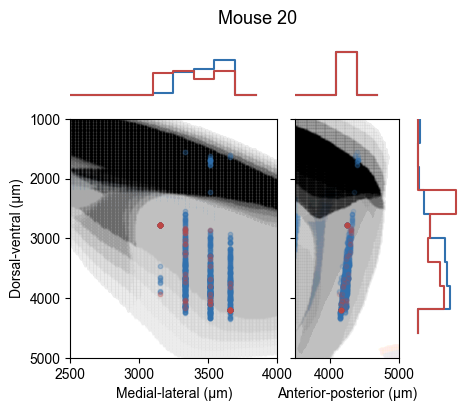

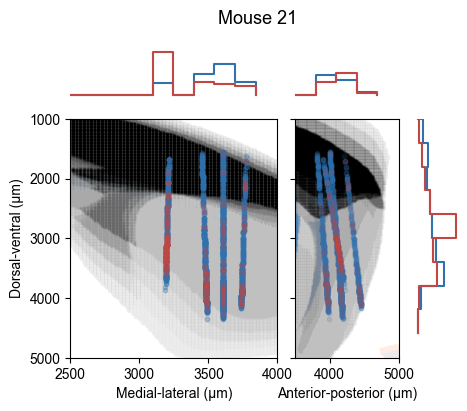

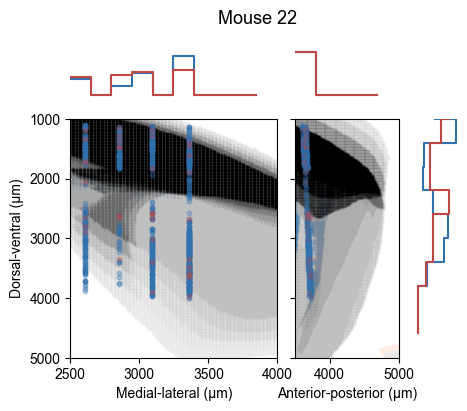

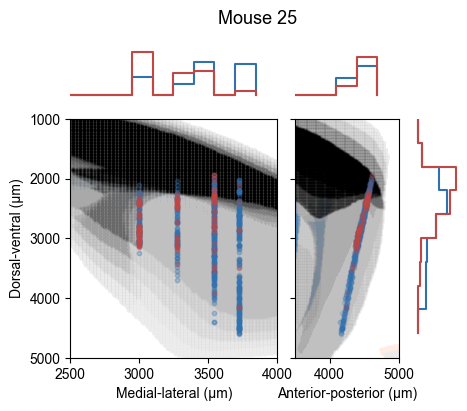

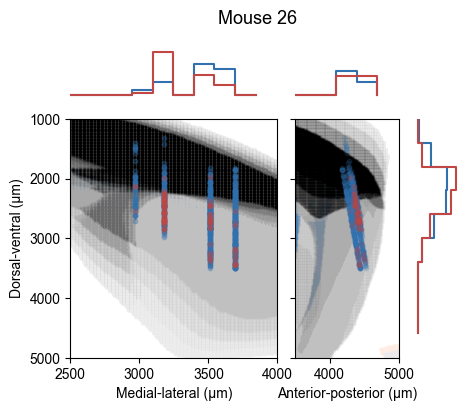

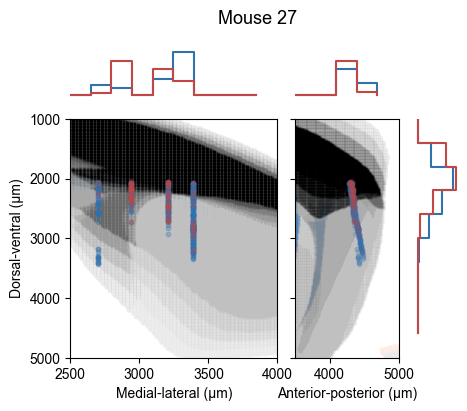

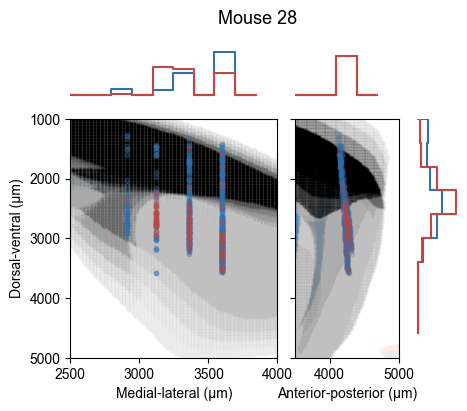

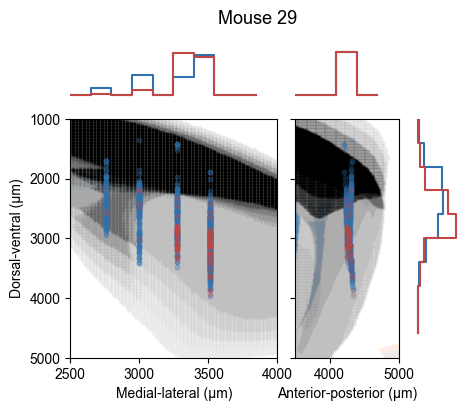

In [8]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch

# Prepare data
ml_ns = ns_['coord_SCs_x'] * -1
ml_ngs = ngs_['coord_SCs_x'] * -1
ml_gcs = gcs_['coord_SCs_x'] * -1

dv_ns = ns_['coord_SCs_y']
dv_ngs = ngs_['coord_SCs_y']
dv_gcs = gcs_['coord_SCs_y']

ap_ns = ns_['coord_SCs_z']
ap_ngs = ngs_['coord_SCs_z']
ap_gcs = gcs_['coord_SCs_z']

# AP slices for annotation overlay (bottom left plot only)
ap_slices = [4000, 4100, 4200, 4300, 4400]
ap_indices = [np.where(ap_axis == ap)[0][0] for ap in ap_slices]

# ML slices for annotation overlay (bottom middle plot only)
ml_slices = [2800, 3100, 3400, 3700]
ml_indices = [np.where(ml_axis == ml)[0][0] for ml in ml_slices]

# Color legend for annotation
legend_labels = {
    'silver': 'ENT',
    'black': 'VIS',
    'grey': 'RSP',
    'cyan': 'SUB',
    'dimgrey': 'PAR/PRE',
    'yellow': 'HPF',
    'black': 'root/other'
}

# Get unique mouse IDs from gcs_ and ngs_ (assumes 'mouse' column exists)
mouse_ids = np.unique(np.concatenate([gcs_['mouse'], ngs_['mouse']]))

for mouse in mouse_ids:
    # Filter data for this mouse
    ml_ngs_mouse = ngs_[ngs_['mouse'] == mouse]['coord_SCs_x'] * -1
    ml_gcs_mouse = gcs_[gcs_['mouse'] == mouse]['coord_SCs_x'] * -1
    dv_ngs_mouse = ngs_[ngs_['mouse'] == mouse]['coord_SCs_y']
    dv_gcs_mouse = gcs_[gcs_['mouse'] == mouse]['coord_SCs_y']
    ap_ngs_mouse = ngs_[ngs_['mouse'] == mouse]['coord_SCs_z']
    ap_gcs_mouse = gcs_[gcs_['mouse'] == mouse]['coord_SCs_z']

    fig, axes = plt.subplots(2, 3, figsize=(5, 4), width_ratios=[1, 0.5, 0.2], height_ratios=[0.2, 1], gridspec_kw={'wspace': 0.15, 'hspace': 0.15}, sharex='col', sharey='row')
    fig.suptitle(f'Mouse {int(mouse)}', fontsize=13)

    # Top left: ML step histogram
    ml_bins = np.linspace(ml_axis.min(), ml_axis.max(), 11)
    ml_hist_ngs, _ = np.histogram(ml_ngs_mouse, bins=ml_bins, density=True)
    ml_hist_gcs, _ = np.histogram(ml_gcs_mouse, bins=ml_bins, density=True)
    axes[0, 0].step(ml_bins[:-1], ml_hist_ngs, where='post', color='#3171ae', label='ngs')
    axes[0, 0].step(ml_bins[:-1], ml_hist_gcs, where='post', color='#c04744', label='gcs')
    axes[0, 0].axis('off')

    # Top middle: AP step histogram
    ap_bins = np.linspace(ap_axis.min(), ap_axis.max(), 6)
    ap_hist_ngs, _ = np.histogram(ap_ngs_mouse, bins=ap_bins, density=True)
    ap_hist_gcs, _ = np.histogram(ap_gcs_mouse, bins=ap_bins, density=True)
    axes[0, 1].step(ap_bins[:-1], ap_hist_ngs, where='post', color='#3171ae', label='ngs')
    axes[0, 1].step(ap_bins[:-1], ap_hist_gcs, where='post', color='#c04744', label='gcs')
    axes[0, 1].axis('off')

    # Top right: DV step histogram (horizontal)
    dv_bins = np.linspace(dv_axis.min(), dv_axis.max(), 11)
    dv_hist_ngs, _ = np.histogram(dv_ngs_mouse, bins=dv_bins, density=True)
    dv_hist_gcs, _ = np.histogram(dv_gcs_mouse, bins=dv_bins, density=True)
    axes[1, 2].step(dv_hist_ngs, dv_bins[:-1], where='post', color='#3171ae', label='ngs')
    axes[1, 2].step(dv_hist_gcs, dv_bins[:-1], where='post', color='#c04744', label='gcs')
    axes[1, 2].axis('off')

    # Bottom left: ML vs DV scatter with annotation overlays for AP slices
    ax_ml_dv = axes[1, 0]
    for ap_idx, ap_val in zip(ap_indices, ap_slices):
        ap_colors_i = annotation_colors[ap_idx, :, :]
        ap_annotations_i = annotations[ap_idx, :, :]
        unique_colors = np.unique(ap_colors_i)
        for color in unique_colors:
            points = extract_border(ap_colors_i, color, only_border=False)
            ml_points = ml_axis[points[:, 1]]
            dv_points = dv_axis[points[:, 0]]
            ax_ml_dv.scatter(ml_points, dv_points, color=color, s=1, alpha=0.05, zorder=1, rasterized=True)
    ax_ml_dv.scatter(ml_ngs_mouse, dv_ngs_mouse, color='#3171ae', alpha=0.3, s=10, label='ngs', zorder=2)
    ax_ml_dv.scatter(ml_gcs_mouse, dv_gcs_mouse, color='#c04744', alpha=0.3, s=10, label='gcs', zorder=2)
    ax_ml_dv.set_xlim(2500, 4000)
    ax_ml_dv.set_ylim(1000, 5000)
    ax_ml_dv.set_yticks([1000, 2000, 3000, 4000, 5000])
    ax_ml_dv.invert_yaxis()
    ax_ml_dv.set_xlabel('Medial-lateral (µm)')
    ax_ml_dv.set_ylabel('Dorsal-ventral (µm)')

    # Bottom middle: AP vs DV scatter (no annotation overlay)
    ax_ap_dv = axes[1, 1]
    for ml_idx, ml_val in zip(ml_indices, ml_slices):
        ml_colors_i = annotation_colors[:, :, ml_idx]
        unique_colors = np.unique(ml_colors_i)
        for color in unique_colors:
            points = extract_border(ml_colors_i, color, only_border=False)
            ap_points = ap_axis[points[:, 0]]
            dv_points = dv_axis[points[:, 1]]
            ax_ap_dv.scatter(ap_points, dv_points, color=color, s=1, alpha=0.05, zorder=1, rasterized=True)
    ax_ap_dv.scatter(ap_ngs_mouse, dv_ngs_mouse, color='#3171ae', alpha=0.15, s=10, label='ngs')
    ax_ap_dv.scatter(ap_gcs_mouse, dv_gcs_mouse, color='#c04744', alpha=0.15, s=10, label='gcs')
    ax_ap_dv.set_xlim(3500, 5000)
    ax_ap_dv.set_xlabel('Anterior-posterior (µm)')

    # Bottom right: blank
    axes[0, 2].axis('off')

    plt.tight_layout()
    plt.savefig(f'/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_2_anatomy_of_spatial_cells/cluster_locations_joint_grid_with_annotations_overlay_step_mouse_{mouse}.pdf', bbox_inches='tight', dpi=300)
    plt.show()

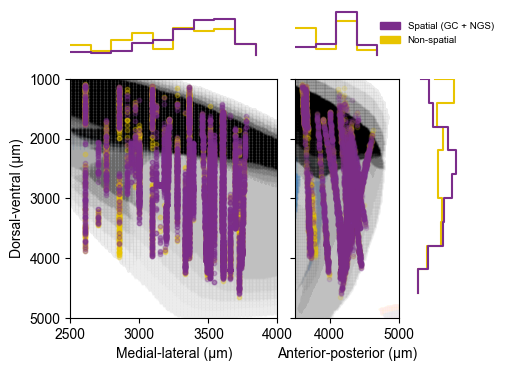

In [9]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch

# Prepare data — spatial (gcs + ngs) vs non-spatial (ns_)
ml_spatial = sc_['coord_SCs_x'] * -1
ml_ns = ns_['coord_SCs_x'] * -1

dv_spatial = sc_['coord_SCs_y']
dv_ns = ns_['coord_SCs_y']

ap_spatial = sc_['coord_SCs_z']
ap_ns = ns_['coord_SCs_z']

# AP slices for annotation overlay (bottom left plot only)
ap_slices = [4000, 4100, 4200, 4300, 4400]
ap_indices_plot = [np.where(ap_axis == ap)[0][0] for ap in ap_slices]

# ML slices for annotation overlay (bottom middle plot only)
ml_slices = [2800, 3100, 3400, 3700]
ml_indices_plot = [np.where(ml_axis == ml)[0][0] for ml in ml_slices]

spatial_color = '#7b2d8b'   # purple
ns_color      = '#e8c400'   # yellow

fig, axes = plt.subplots(2, 3, figsize=(5, 4),
                          width_ratios=[1, 0.5, 0.2],
                          height_ratios=[0.2, 1],
                          gridspec_kw={'wspace': 0.15, 'hspace': 0.15},
                          sharex='col', sharey='row')

# --- Top left: ML step histogram ---
ml_bins = np.linspace(ml_axis.min(), ml_axis.max(), 11)
ml_hist_ns, _       = np.histogram(ml_ns,      bins=ml_bins, density=True)
ml_hist_spatial, _  = np.histogram(ml_spatial, bins=ml_bins, density=True)
axes[0, 0].step(ml_bins[:-1], ml_hist_ns,      where='post', color=ns_color,      label='non-spatial')
axes[0, 0].step(ml_bins[:-1], ml_hist_spatial, where='post', color=spatial_color, label='spatial')
axes[0, 0].axis('off')

# --- Top middle: AP step histogram ---
ap_bins = np.linspace(ap_axis.min(), ap_axis.max(), 6)
ap_hist_ns, _       = np.histogram(ap_ns,      bins=ap_bins, density=True)
ap_hist_spatial, _  = np.histogram(ap_spatial, bins=ap_bins, density=True)
axes[0, 1].step(ap_bins[:-1], ap_hist_ns,      where='post', color=ns_color,      label='non-spatial')
axes[0, 1].step(ap_bins[:-1], ap_hist_spatial, where='post', color=spatial_color, label='spatial')
axes[0, 1].axis('off')

# --- Right column: DV step histogram (horizontal) ---
dv_bins = np.linspace(dv_axis.min(), dv_axis.max(), 11)
dv_hist_ns, _       = np.histogram(dv_ns,      bins=dv_bins, density=True)
dv_hist_spatial, _  = np.histogram(dv_spatial, bins=dv_bins, density=True)
axes[1, 2].step(dv_hist_ns,      dv_bins[:-1], where='post', color=ns_color,      label='non-spatial')
axes[1, 2].step(dv_hist_spatial, dv_bins[:-1], where='post', color=spatial_color, label='spatial')
axes[1, 2].axis('off')

# --- Bottom left: ML vs DV scatter with annotation overlay ---
ax_ml_dv = axes[1, 0]
for ap_idx, ap_val in zip(ap_indices_plot, ap_slices):
    ap_colors_i = annotation_colors[ap_idx, :, :]
    unique_colors = np.unique(ap_colors_i)
    for color in unique_colors:
        points = extract_border(ap_colors_i, color, only_border=False)
        ml_points = ml_axis[points[:, 1]]
        dv_points = dv_axis[points[:, 0]]
        ax_ml_dv.scatter(ml_points, dv_points, color=color, s=1, alpha=0.05, zorder=1, rasterized=True)
ax_ml_dv.scatter(ml_ns,      dv_ns,      color=ns_color,      alpha=0.3, s=10, label='non-spatial', zorder=2)
ax_ml_dv.scatter(ml_spatial, dv_spatial, color=spatial_color, alpha=0.3, s=10, label='spatial',      zorder=2)
ax_ml_dv.set_xlim(2500, 4000)
ax_ml_dv.set_ylim(1000, 5000)
ax_ml_dv.set_yticks([1000, 2000, 3000, 4000, 5000])
ax_ml_dv.invert_yaxis()
ax_ml_dv.set_xlabel('Medial-lateral (µm)')
ax_ml_dv.set_ylabel('Dorsal-ventral (µm)')

# --- Bottom middle: AP vs DV scatter with annotation overlay ---
ax_ap_dv = axes[1, 1]
for ml_idx, ml_val in zip(ml_indices_plot, ml_slices):
    ml_colors_i = annotation_colors[:, :, ml_idx]
    unique_colors = np.unique(ml_colors_i)
    for color in unique_colors:
        points = extract_border(ml_colors_i, color, only_border=False)
        ap_pts = ap_axis[points[:, 0]]
        dv_pts = dv_axis[points[:, 1]]
        ax_ap_dv.scatter(ap_pts, dv_pts, color=color, s=1, alpha=0.05, zorder=1, rasterized=True)
ax_ap_dv.scatter(ap_ns,      dv_ns,      color=ns_color,      alpha=0.15, s=10, label='non-spatial')
ax_ap_dv.scatter(ap_spatial, dv_spatial, color=spatial_color, alpha=0.15, s=10, label='spatial')
ax_ap_dv.set_xlim(3500, 5000)
ax_ap_dv.set_xlabel('Anterior-posterior (µm)')

# --- Top right: blank ---
axes[0, 2].axis('off')

legend_handles = [
    Patch(color=spatial_color, label='Spatial (GC + NGS)'),
    Patch(color=ns_color,      label='Non-spatial'),
]
axes[0, 2].legend(handles=legend_handles, loc='center', frameon=False, fontsize=7)

plt.tight_layout()
plt.savefig('/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_2_anatomy_of_spatial_cells/cluster_locations_spatial_vs_nonspatial_overlay_step.pdf', bbox_inches='tight', dpi=300)
plt.show()


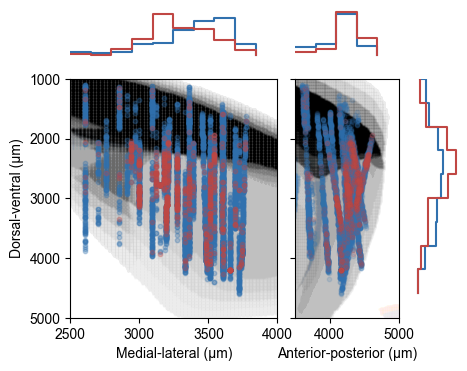

In [10]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch

# Prepare data
ml_ns = ns_['coord_SCs_x'] * -1
ml_ngs = ngs_['coord_SCs_x'] * -1
ml_gcs = gcs_['coord_SCs_x'] * -1

dv_ns = ns_['coord_SCs_y']
dv_ngs = ngs_['coord_SCs_y']
dv_gcs = gcs_['coord_SCs_y']

ap_ns = ns_['coord_SCs_z']
ap_ngs = ngs_['coord_SCs_z']
ap_gcs = gcs_['coord_SCs_z']

# AP slices for annotation overlay (bottom left plot only)
ap_slices = [4000, 4100, 4200, 4300, 4400]
ap_indices = [np.where(ap_axis == ap)[0][0] for ap in ap_slices]

# ML slices for annotation overlay (bottom middle plot only)
ml_slices = [2800, 3100, 3400, 3700]
ml_indices = [np.where(ml_axis == ml)[0][0] for ml in ml_slices]

# Color legend for annotation
legend_labels = {
    'silver': 'ENT',
    'black': 'VIS',
    'grey': 'RSP',
    'cyan': 'SUB',
    'dimgrey': 'PAR/PRE',
    'yellow': 'HPF',
    'black': 'root/other'
}

fig, axes = plt.subplots(2, 3, figsize=(5, 4), width_ratios=[1, 0.5, 0.2], height_ratios=[0.2, 1], gridspec_kw={'wspace': 0.15, 'hspace': 0.15}, sharex='col', sharey='row')

# Top left: ML step histogram
ml_bins = np.linspace(ml_axis.min(), ml_axis.max(), 11)
ml_hist_ngs, _ = np.histogram(ml_ngs, bins=ml_bins, density=True)
ml_hist_gcs, _ = np.histogram(ml_gcs, bins=ml_bins, density=True)
axes[0, 0].step(ml_bins[:-1], ml_hist_ngs, where='post', color='#3171ae', label='ngs')
axes[0, 0].step(ml_bins[:-1], ml_hist_gcs, where='post', color='#c04744', label='gcs')
axes[0, 0].axis('off')

# Top middle: AP step histogram
ap_bins = np.linspace(ap_axis.min(), ap_axis.max(), 6)
ap_hist_ngs, _ = np.histogram(ap_ngs, bins=ap_bins, density=True)
ap_hist_gcs, _ = np.histogram(ap_gcs, bins=ap_bins, density=True)
axes[0, 1].step(ap_bins[:-1], ap_hist_ngs, where='post', color='#3171ae', label='ngs')
axes[0, 1].step(ap_bins[:-1], ap_hist_gcs, where='post', color='#c04744', label='gcs')
axes[0, 1].axis('off')

# Top right: DV step histogram (horizontal)
dv_bins = np.linspace(dv_axis.min(), dv_axis.max(), 11)
dv_hist_ngs, _ = np.histogram(dv_ngs, bins=dv_bins, density=True)
dv_hist_gcs, _ = np.histogram(dv_gcs, bins=dv_bins, density=True)
axes[1, 2].step(dv_hist_ngs, dv_bins[:-1], where='post', color='#3171ae', label='ngs')
axes[1, 2].step(dv_hist_gcs, dv_bins[:-1], where='post', color='#c04744', label='gcs')
axes[1, 2].axis('off')

# Bottom left: ML vs DV scatter with annotation overlays for AP=4200, 4300, 4400
ax_ml_dv = axes[1, 0]
for ap_idx, ap_val in zip(ap_indices, ap_slices):
    ap_colors_i = annotation_colors[ap_idx, :, :]
    ap_annotations_i = annotations[ap_idx, :, :]
    unique_colors = np.unique(ap_colors_i)
    for color in unique_colors:
        points = extract_border(ap_colors_i, color, only_border=False)
        ml_points = ml_axis[points[:, 1]]
        dv_points = dv_axis[points[:, 0]]
        ax_ml_dv.scatter(ml_points, dv_points, color=color, s=1, alpha=0.05, zorder=1, rasterized=True)
ax_ml_dv.scatter(ml_ngs, dv_ngs, color='#3171ae', alpha=0.3, s=10, label='ngs', zorder=2)
ax_ml_dv.scatter(ml_gcs, dv_gcs, color='#c04744', alpha=0.3, s=10, label='gcs', zorder=2)
ax_ml_dv.set_xlim(2500, 4000)
ax_ml_dv.set_ylim(1000, 5000)
ax_ml_dv.set_yticks([1000, 2000, 3000, 4000, 5000])
ax_ml_dv.invert_yaxis()
ax_ml_dv.set_xlabel('Medial-lateral (µm)')
ax_ml_dv.set_ylabel('Dorsal-ventral (µm)')

# Bottom middle: AP vs DV scatter (no annotation overlay)
ax_ap_dv = axes[1, 1]
for ml_idx, ml_val in zip(ml_indices, ml_slices):
    ml_colors_i = annotation_colors[:, :, ml_idx]
    unique_colors = np.unique(ml_colors_i)
    for color in unique_colors:
        points = extract_border(ml_colors_i, color, only_border=False)
        ap_points = ap_axis[points[:, 0]]
        dv_points = dv_axis[points[:, 1]]
        ax_ap_dv.scatter(ap_points, dv_points, color=color, s=1, alpha=0.05, zorder=1, rasterized=True)
axes[1, 1].scatter(ap_ngs, dv_ngs, color='#3171ae', alpha=0.15, s=10, label='ngs')
axes[1, 1].scatter(ap_gcs, dv_gcs, color='#c04744', alpha=0.15, s=10, label='gcs')
axes[1, 1].set_xlim(3500, 5000)
axes[1, 1].set_xlabel('Anterior-posterior (µm)')

# Bottom right: blank
axes[0, 2].axis('off')

plt.tight_layout()
plt.savefig('/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_2_anatomy_of_spatial_cells/cluster_locations_joint_grid_with_annotations_overlay_step.pdf', bbox_inches='tight', dpi=300)
plt.show()

In [11]:
device_contacts = pd.read_csv('/Users/harryclark/Downloads/device_contact_id_annotations.csv')

In [ ]:
import numpy as np
import pandas as pd
import math
import plotly.graph_objects as go

# ── coordinate conversion ────────────────────────────────────────────────────
def stereo_to_ccf(SC, angle=-0.0873):
    SC = np.asarray(SC, float)
    stretch = SC / np.array([1.0, 0.9434, 1.0])
    rotate = np.array([
        stretch[0]*math.cos(angle) - stretch[1]*math.sin(angle),
        stretch[0]*math.sin(angle) + stretch[1]*math.cos(angle),
        stretch[2]
    ])
    return rotate + np.array([5400.0, 440.0, 5700.0])

def df_to_ccf(df):
    coords = df[['SC_x', 'SC_y', 'SC_z']].values
    return np.array([stereo_to_ccf(r) for r in coords])

# ── obj mesh loader ──────────────────────────────────────────────────────────
def load_obj(path):
    verts, faces = [], []
    with open(path) as fh:
        for line in fh:
            if line.startswith('v '):
                verts.append(list(map(float, line.split()[1:])))
            elif line.startswith('f '):
                face = [int(x.split('/')[0]) - 1 for x in line.split()[1:]]
                if len(face) == 3:
                    faces.append(face)
                elif len(face) == 4:          # quad → two triangles
                    faces.append(face[:3])
                    faces.append([face[0], face[2], face[3]])
    v = np.array(verts)
    f = np.array(faces)
    return v, f

def mesh_trace(path, name, color, opacity=0.08, showlegend=True):
    v, f = load_obj(path)
    return go.Mesh3d(
        x=v[:, 0], y=v[:, 2], z=-v[:, 1],   # x=AP, y=ML, z=DV (flip DV so dorsal is up)
        i=f[:, 0], j=f[:, 1], k=f[:, 2],
        color=color, opacity=opacity,
        name=name, showlegend=showlegend,
        flatshading=False,
        lighting=dict(ambient=0.6, diffuse=0.8),
    )

# ── data ─────────────────────────────────────────────────────────────────────
ATLAS = '/Users/harryclark/.brainglobe/allen_mouse_10um_v1.2/meshes'

df = pd.read_csv('/Users/harryclark/Documents/spatial-manifolds/data/cell_classifications.csv')
gc  = df[df['cell_type'] == 'GC'].dropna(subset=['SC_x', 'SC_y', 'SC_z'])
ngs = df[df['cell_type'] == 'NG'].dropna(subset=['SC_x', 'SC_y', 'SC_z'])

gc_ccf  = df_to_ccf(gc)
ngs_ccf = df_to_ccf(ngs)

# ── build figure ─────────────────────────────────────────────────────────────
# structure IDs: 997=root, 909=ENT, 1089=HPF, 843=PAR, 1084=PRE, 502=SUB
structures = [
    (997,  'Brain',  'lightgrey',  0.05),
    (909,  'ENT',   'steelblue',  0.18),
    (1089, 'HPF',   'lightblue',  0.12),
    (843,  'PAR',   'orchid',     0.20),
    (1084, 'PRE',   'mediumseagreen', 0.20),
    (502,  'SUB',   'goldenrod',  0.15),
]

traces = [mesh_trace(f'{ATLAS}/{sid}.obj', name, col, op)
          for sid, name, col, op in structures]

# cell scatter traces (x=AP, y=ML, z=DV flipped)
for ccf_coords, label, color, symbol in [
    (gc_ccf,  'Grid cells (GC)',     '#e74c3c', 'circle'),
    (ngs_ccf, 'Non-grid spatial (NGS)', '#3498db', 'circle'),
]:
    traces.append(go.Scatter3d(
        x=ccf_coords[:, 0],
        y=ccf_coords[:, 2],
        z=-ccf_coords[:, 1],
        mode='markers',
        marker=dict(size=3, color=color, opacity=0.8, symbol=symbol),
        name=label,
    ))

fig = go.Figure(data=traces)
fig.update_layout(
    scene=dict(
        xaxis_title='Anterior → Posterior (μm)',
        yaxis_title='Medial → Lateral (μm)',
        zaxis_title='Ventral → Dorsal (μm)',
        aspectmode='data',
        bgcolor='white',
    ),
    legend=dict(itemsizing='constant'),
    title='Grid cells and non-grid spatial cells — Allen CCF',
    width=900, height=700,
)
fig.show()


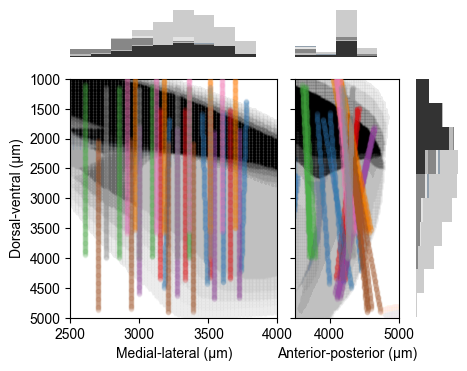

In [12]:
import matplotlib.pyplot as plt
import numpy as np

# Assign a color for each mouse
mouse_colors = [
    "#e41a1c", "#377eb8", "#4daf4a", "#984ea3", "#ff7f00", "#a65628", "#f781bf", "#999999"
]
mouse_ids = device_contacts['mouse'].unique()
mouse_color_map = {mouse: mouse_colors[i % len(mouse_colors)] for i, mouse in enumerate(mouse_ids)}

# Prepare data for all contacts
ml_contacts = device_contacts['coord_SCs_x'] * -1
ap_contacts = device_contacts['coord_SCs_z']
dv_contacts = device_contacts['coord_SCs_y']

# Helper: get annotation color for each contact
def get_annotation_color(df):
    ap_idx = np.round((df['coord_SCs_z'] - ap_axis[0]) / (ap_axis[1] - ap_axis[0])).astype(int)
    dv_idx = np.round((df['coord_SCs_y'] - dv_axis[0]) / (dv_axis[1] - dv_axis[0])).astype(int)
    ml_idx = np.round((-df['coord_SCs_x'] - ml_axis[0]) / (ml_axis[1] - ml_axis[0])).astype(int)
    colors = []
    for a, d, m in zip(ap_idx, dv_idx, ml_idx):
        if (0 <= a < len(ap_axis)) and (0 <= d < len(dv_axis)) and (0 <= m < len(ml_axis)):
            colors.append(annotation_colors[a, d, m])
        else:
            colors.append('white')
    return np.array(colors)

contact_colors = get_annotation_color(device_contacts)

# Binning
ml_bins = np.linspace(ml_axis.min(), ml_axis.max(), 11)
ap_bins = np.linspace(ap_axis.min(), ap_axis.max(), 6)
dv_bins = np.linspace(dv_axis.min(), dv_axis.max(), 11)

# Get all unique region colors (excluding white)
all_colors = np.unique(annotation_colors)
region_colors = [c for c in all_colors if c != 'white']

# ML histogram: stacked by region color
ml_hist_region = {color: [] for color in region_colors}
for i in range(len(ml_bins) - 1):
    in_bin = (ml_contacts >= ml_bins[i]) & (ml_contacts < ml_bins[i+1])
    for color in region_colors:
        ml_hist_region[color].append(np.sum(in_bin & (contact_colors == color)))
for color in region_colors:
    ml_hist_region[color] = np.array(ml_hist_region[color])

# AP histogram: stacked by region color
ap_hist_region = {color: [] for color in region_colors}
for i in range(len(ap_bins) - 1):
    in_bin = (ap_contacts >= ap_bins[i]) & (ap_contacts < ap_bins[i+1])
    for color in region_colors:
        ap_hist_region[color].append(np.sum(in_bin & (contact_colors == color)))
for color in region_colors:
    ap_hist_region[color] = np.array(ap_hist_region[color])

# DV histogram: stacked by region color
dv_hist_region = {color: [] for color in region_colors}
for i in range(len(dv_bins) - 1):
    in_bin = (dv_contacts >= dv_bins[i]) & (dv_contacts < dv_bins[i+1])
    for color in region_colors:
        dv_hist_region[color].append(np.sum(in_bin & (contact_colors == color)))
for color in region_colors:
    dv_hist_region[color] = np.array(dv_hist_region[color])

# Slices for annotation overlays
ap_slices = [4000, 4100, 4200, 4300, 4400]
ap_indices = [np.where(ap_axis == ap)[0][0] for ap in ap_slices]
ml_slices = [2800, 3100, 3400, 3700]
ml_indices = [np.where(ml_axis == ml)[0][0] for ml in ml_slices]

fig, axes = plt.subplots(2, 3, figsize=(5, 4), width_ratios=[1, 0.5, 0.2], height_ratios=[0.2, 1], gridspec_kw={'wspace': 0.15, 'hspace': 0.15}, sharex='col', sharey=False)

# Top left: ML histogram (stacked by region)
bottom = np.zeros(len(ml_bins)-1)
for color in region_colors:
    axes[0, 0].bar(ml_bins[:-1], ml_hist_region[color], width=np.diff(ml_bins), color=color, alpha=0.8, align='edge', bottom=bottom, label=color)
    bottom += ml_hist_region[color]
axes[0, 0].axis('off')

# Top middle: AP histogram (stacked by region)
bottom = np.zeros(len(ap_bins)-1)
for color in region_colors:
    axes[0, 1].bar(ap_bins[:-1], ap_hist_region[color], width=np.diff(ap_bins), color=color, alpha=0.8, align='edge', bottom=bottom, label=color)
    bottom += ap_hist_region[color]
axes[0, 1].axis('off')

# Top right: DV histogram (stacked by region, horizontal)
bottom = np.zeros(len(dv_bins)-1)
for color in region_colors:
    axes[1, 2].barh(dv_bins[:-1], dv_hist_region[color], height=np.diff(dv_bins), color=color, alpha=0.8, align='edge', left=bottom, label=color)
    bottom += dv_hist_region[color]
axes[1, 2].axis('off')

# Bottom left: ML vs DV scatter with annotation overlays for AP slices
ax_ml_dv = axes[1, 0]
for ap_idx, ap_val in zip(ap_indices, ap_slices):
    ap_colors_i = annotation_colors[ap_idx, :, :]
    unique_colors = np.unique(ap_colors_i)
    for color in unique_colors:
        points = extract_border(ap_colors_i, color, only_border=False)
        if len(points) == 0:
            continue
        ml_points = ml_axis[points[:, 1]]
        dv_points = dv_axis[points[:, 0]]
        ax_ml_dv.scatter(ml_points, dv_points, color=color, s=1, alpha=0.05, zorder=1, rasterized=True)
# Plot all contacts, colored by mouse
for i, mouse in enumerate(mouse_ids):
    df_mouse = device_contacts[device_contacts['mouse'] == mouse]
    ax_ml_dv.scatter(
        df_mouse['coord_SCs_x'] * -1,
        df_mouse['coord_SCs_y'],
        color=mouse_color_map[mouse],
        label=f"Mouse {mouse}",
        s=10,
        alpha=0.05,
        marker='o',
        zorder=3
    )
ax_ml_dv.set_xlim(2500, 4000)
ax_ml_dv.set_ylim(1000, 5000)
ax_ml_dv.invert_yaxis()
ax_ml_dv.set_xlabel('Medial-lateral (µm)')
ax_ml_dv.set_ylabel('Dorsal-ventral (µm)')

# Bottom middle: AP vs DV scatter with annotation overlays for ML slices
ax_ap_dv = axes[1, 1]
for ml_idx, ml_val in zip(ml_indices, ml_slices):
    ml_colors_i = annotation_colors[:, :, ml_idx]
    unique_colors = np.unique(ml_colors_i)
    for color in unique_colors:
        points = extract_border(ml_colors_i, color, only_border=False)
        if len(points) == 0:
            continue
        ap_points = ap_axis[points[:, 0]]
        dv_points = dv_axis[points[:, 1]]
        ax_ap_dv.scatter(ap_points, dv_points, color=color, s=1, alpha=0.05, zorder=1, rasterized=True)
# Plot all contacts, colored by mouse
for i, mouse in enumerate(mouse_ids):
    df_mouse = device_contacts[device_contacts['mouse'] == mouse]
    ax_ap_dv.scatter(
        df_mouse['coord_SCs_z'],
        df_mouse['coord_SCs_y'],
        color=mouse_color_map[mouse],
        label=f"Mouse {mouse}",
        s=10,
        alpha=0.05,
        marker='o',
        zorder=3
    )
ax_ap_dv.set_xlim(3500, 5000)
ax_ap_dv.set_xlabel('Anterior-posterior (µm)')

# Bottom right: blank
axes[0, 2].axis('off')
axes[1,1].set_ylim(1000, 5000)
axes[1,2].set_ylim(1000, 5000)
axes[1,1].invert_yaxis()
axes[1,2].invert_yaxis()
axes[1,1].set_yticklabels([])
plt.tight_layout()
plt.savefig('/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_2_anatomy_of_spatial_cells/device_contacts_joint_grid_with_annotations_overlay_regions.pdf', bbox_inches='tight', dpi=300)
plt.show()

In [13]:
import matplotlib.pyplot as plt
import numpy as np

# Only consider cells in ENT region
def get_ent_mask(df):
    ap_idx = np.round((df['coord_SCs_z'] - ap_axis[0]) / (ap_axis[1] - ap_axis[0])).astype(int)
    dv_idx = np.round((df['coord_SCs_y'] - dv_axis[0]) / (dv_axis[1] - dv_axis[0])).astype(int)
    ml_idx = np.round((-df['coord_SCs_x'] - ml_axis[0]) / (ml_axis[1] - ml_axis[0])).astype(int)
    mask = []
    for a, d, m in zip(ap_idx, dv_idx, ml_idx):
        if (0 <= a < len(ap_axis)) and (0 <= d < len(dv_axis)) and (0 <= m < len(ml_axis)):
            mask.append(annotation_colors[a, d, m] == 'silver')
        else:
            mask.append(False)
    return np.array(mask)

gcs_ent = gcs_[get_ent_mask(gcs_)]
ngs_ent = ngs_[get_ent_mask(ngs_)]

# Bin size (100 µm)
ml_bins = np.arange(ml_axis.min(), ml_axis.max() + 100, 100)
ap_bins = np.arange(ap_axis.min(), ap_axis.max() + 100, 100)
dv_bins = np.arange(dv_axis.min(), dv_axis.max() + 100, 100)

# Device contacts
ml_contacts = device_contacts['coord_SCs_x'] * -1
ap_contacts = device_contacts['coord_SCs_z']
dv_contacts = device_contacts['coord_SCs_y']

# Only consider device contacts in ENT region
def get_ent_contact_mask(df):
    ap_idx = np.round((df['coord_SCs_z'] - ap_axis[0]) / (ap_axis[1] - ap_axis[0])).astype(int)
    dv_idx = np.round((df['coord_SCs_y'] - dv_axis[0]) / (dv_axis[1] - dv_axis[0])).astype(int)
    ml_idx = np.round((-df['coord_SCs_x'] - ml_axis[0]) / (ml_axis[1] - ml_axis[0])).astype(int)
    mask = []
    for a, d, m in zip(ap_idx, dv_idx, ml_idx):
        if (0 <= a < len(ap_axis)) and (0 <= d < len(dv_axis)) and (0 <= m < len(ml_axis)):
            mask.append(annotation_colors[a, d, m] == 'silver')
        else:
            mask.append(False)
    return np.array(mask)

ent_contact_mask = get_ent_contact_mask(device_contacts)
ent_contacts = device_contacts[ent_contact_mask]
ml_contacts_ent = ml_contacts[ent_contact_mask]
ap_contacts_ent = ap_contacts[ent_contact_mask]
dv_contacts_ent = dv_contacts[ent_contact_mask]

# Grid cells (ENT only)
ml_gcs_ent = gcs_ent['coord_SCs_x'] * -1
ap_gcs_ent = gcs_ent['coord_SCs_z']
dv_gcs_ent = gcs_ent['coord_SCs_y']

# Non-grid cells (ENT only)
ml_ngs_ent = ngs_ent['coord_SCs_x'] * -1
ap_ngs_ent = ngs_ent['coord_SCs_z']
dv_ngs_ent = ngs_ent['coord_SCs_y']

# Helper for safe division
def safe_divide(a, b):
    out = np.zeros_like(a, dtype=float)
    mask = b > 0
    out[mask] = a[mask] / b[mask]
    out[~mask] = np.nan
    return out

# ML axis
contacts_ml, _ = np.histogram(ml_contacts_ent, bins=ml_bins)
gcs_ml, _ = np.histogram(ml_gcs_ent, bins=ml_bins)
ngs_ml, _ = np.histogram(ml_ngs_ent, bins=ml_bins)
gcs_per_contact_ml = safe_divide(gcs_ml, contacts_ml)
ngs_per_contact_ml = safe_divide(ngs_ml, contacts_ml)

# AP axis
contacts_ap, _ = np.histogram(ap_contacts_ent, bins=ap_bins)
gcs_ap, _ = np.histogram(ap_gcs_ent, bins=ap_bins)
ngs_ap, _ = np.histogram(ap_ngs_ent, bins=ap_bins)
gcs_per_contact_ap = safe_divide(gcs_ap, contacts_ap)
ngs_per_contact_ap = safe_divide(ngs_ap, contacts_ap)

# DV axis
contacts_dv, _ = np.histogram(dv_contacts_ent, bins=dv_bins)
gcs_dv, _ = np.histogram(dv_gcs_ent, bins=dv_bins)
ngs_dv, _ = np.histogram(dv_ngs_ent, bins=dv_bins)
gcs_per_contact_dv = safe_divide(gcs_dv, contacts_dv)
ngs_per_contact_dv = safe_divide(ngs_dv, contacts_dv)

# Cumulative density for each axis
def cumulative_density(hist):
    cumsum = np.nancumsum(hist)
    if np.nansum(hist) > 0:
        return cumsum / np.nansum(hist)
    else:
        return np.full_like(hist, np.nan, dtype=float)

gcs_cum_ml = cumulative_density(gcs_ml)
ngs_cum_ml = cumulative_density(ngs_ml)
gcs_cum_ap = cumulative_density(gcs_ap)
ngs_cum_ap = cumulative_density(ngs_ap)
gcs_cum_dv = cumulative_density(gcs_dv)
ngs_cum_dv = cumulative_density(ngs_dv)


In [14]:
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
n_mice = len(mouse_ids)

# --- ML axis ---
n_bins_ml = len(ml_bins) - 1
gcs_cells_per_entcontact_ml = np.full((n_bins_ml, n_mice), np.nan)
ngs_cells_per_entcontact_ml = np.full((n_bins_ml, n_mice), np.nan)

for i_mouse, mouse in enumerate(mouse_ids):
    gcs_mouse = gcs_ent[gcs_ent['mouse'] == mouse]
    contacts_mouse = ent_contacts[ent_contacts['mouse'] == mouse]
    gcs_counts, _ = np.histogram(gcs_mouse['coord_SCs_x'] * -1, bins=ml_bins)
    contact_counts, _ = np.histogram(contacts_mouse['coord_SCs_x'] * -1, bins=ml_bins)
    with np.errstate(divide='ignore', invalid='ignore'):
        per_contact = gcs_counts / contact_counts
    gcs_cells_per_entcontact_ml[:, i_mouse] = per_contact

for i_mouse, mouse in enumerate(mouse_ids):
    ngs_mouse = ngs_ent[ngs_ent['mouse'] == mouse]
    contacts_mouse = ent_contacts[ent_contacts['mouse'] == mouse]
    ngs_counts, _ = np.histogram(ngs_mouse['coord_SCs_x'] * -1, bins=ml_bins)
    contact_counts, _ = np.histogram(contacts_mouse['coord_SCs_x'] * -1, bins=ml_bins)
    with np.errstate(divide='ignore', invalid='ignore'):
        per_contact = ngs_counts / contact_counts
    ngs_cells_per_entcontact_ml[:, i_mouse] = per_contact

data_ml = []
for i_mouse, mouse in enumerate(mouse_ids):
    for i_bin in range(n_bins_ml):
        data_ml.append({
            'value': gcs_cells_per_entcontact_ml[i_bin, i_mouse],
            'group': 'GCS',
            'bin': ml_bins[i_bin],
            'mouse': mouse
        })
        data_ml.append({
            'value': ngs_cells_per_entcontact_ml[i_bin, i_mouse],
            'group': 'NGS',
            'bin': ml_bins[i_bin],
            'mouse': mouse
        })
df_ml = pd.DataFrame(data_ml).dropna(subset=['value'])
model_ml = smf.mixedlm("value ~ group * bin", df_ml, groups=df_ml["mouse"])
result_ml = model_ml.fit(method="powell", maxiter=5000)
print("ML axis GLMM:")
print(result_ml.summary())

# --- AP axis ---
n_bins_ap = len(ap_bins) - 1
gcs_cells_per_entcontact_ap = np.full((n_bins_ap, n_mice), np.nan)
ngs_cells_per_entcontact_ap = np.full((n_bins_ap, n_mice), np.nan)

for i_mouse, mouse in enumerate(mouse_ids):
    gcs_mouse = gcs_ent[gcs_ent['mouse'] == mouse]
    contacts_mouse = ent_contacts[ent_contacts['mouse'] == mouse]
    gcs_counts, _ = np.histogram(gcs_mouse['coord_SCs_z'], bins=ap_bins)
    contact_counts, _ = np.histogram(contacts_mouse['coord_SCs_z'], bins=ap_bins)
    with np.errstate(divide='ignore', invalid='ignore'):
        per_contact = gcs_counts / contact_counts
    gcs_cells_per_entcontact_ap[:, i_mouse] = per_contact

for i_mouse, mouse in enumerate(mouse_ids):
    ngs_mouse = ngs_ent[ngs_ent['mouse'] == mouse]
    contacts_mouse = ent_contacts[ent_contacts['mouse'] == mouse]
    ngs_counts, _ = np.histogram(ngs_mouse['coord_SCs_z'], bins=ap_bins)
    contact_counts, _ = np.histogram(contacts_mouse['coord_SCs_z'], bins=ap_bins)
    with np.errstate(divide='ignore', invalid='ignore'):
        per_contact = ngs_counts / contact_counts
    ngs_cells_per_entcontact_ap[:, i_mouse] = per_contact

data_ap = []
for i_mouse, mouse in enumerate(mouse_ids):
    for i_bin in range(n_bins_ap):
        data_ap.append({
            'value': gcs_cells_per_entcontact_ap[i_bin, i_mouse],
            'group': 'GCS',
            'bin': ap_bins[i_bin],
            'mouse': mouse
        })
        data_ap.append({
            'value': ngs_cells_per_entcontact_ap[i_bin, i_mouse],
            'group': 'NGS',
            'bin': ap_bins[i_bin],
            'mouse': mouse
        })
df_ap = pd.DataFrame(data_ap).dropna(subset=['value'])
model_ap = smf.mixedlm("value ~ group * bin", df_ap, groups=df_ap["mouse"])
result_ap = model_ap.fit(method="powell", maxiter=5000)
print("AP axis GLMM:")
print(result_ap.summary())

# --- DV axis ---
n_bins_dv = len(dv_bins) - 1
gcs_cells_per_entcontact_dv = np.full((n_bins_dv, n_mice), np.nan)
ngs_cells_per_entcontact_dv = np.full((n_bins_dv, n_mice), np.nan)

for i_mouse, mouse in enumerate(mouse_ids):
    gcs_mouse = gcs_ent[gcs_ent['mouse'] == mouse]
    contacts_mouse = ent_contacts[ent_contacts['mouse'] == mouse]
    gcs_counts, _ = np.histogram(gcs_mouse['coord_SCs_y'], bins=dv_bins)
    contact_counts, _ = np.histogram(contacts_mouse['coord_SCs_y'], bins=dv_bins)
    with np.errstate(divide='ignore', invalid='ignore'):
        per_contact = gcs_counts / contact_counts
    gcs_cells_per_entcontact_dv[:, i_mouse] = per_contact

for i_mouse, mouse in enumerate(mouse_ids):
    ngs_mouse = ngs_ent[ngs_ent['mouse'] == mouse]
    contacts_mouse = ent_contacts[ent_contacts['mouse'] == mouse]
    ngs_counts, _ = np.histogram(ngs_mouse['coord_SCs_y'], bins=dv_bins)
    contact_counts, _ = np.histogram(contacts_mouse['coord_SCs_y'], bins=dv_bins)
    with np.errstate(divide='ignore', invalid='ignore'):
        per_contact = ngs_counts / contact_counts
    ngs_cells_per_entcontact_dv[:, i_mouse] = per_contact

data_dv = []
for i_mouse, mouse in enumerate(mouse_ids):
    for i_bin in range(n_bins_dv):
        data_dv.append({
            'value': gcs_cells_per_entcontact_dv[i_bin, i_mouse],
            'group': 'GCS',
            'bin': dv_bins[i_bin],
            'mouse': mouse
        })
        data_dv.append({
            'value': ngs_cells_per_entcontact_dv[i_bin, i_mouse],
            'group': 'NGS',
            'bin': dv_bins[i_bin],
            'mouse': mouse
        })
df_dv = pd.DataFrame(data_dv).dropna(subset=['value'])
model_dv = smf.mixedlm("value ~ group * bin", df_dv, groups=df_dv["mouse"])
result_dv = model_dv.fit(method="powell", maxiter=5000)
print("DV axis GLMM:")
print(result_dv.summary())

ML axis GLMM:
           Mixed Linear Model Regression Results
Model:               MixedLM  Dependent Variable:  value   
No. Observations:    52       Method:              REML    
No. Groups:          8        Scale:               0.1271  
Min. group size:     2        Log-Likelihood:      -38.9423
Max. group size:     10       Converged:           Yes     
Mean group size:     6.5                                   
-----------------------------------------------------------
                 Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-----------------------------------------------------------
Intercept         1.059    1.034  1.024 0.306 -0.967  3.086
group[T.NGS]     -5.211    1.436 -3.629 0.000 -8.025 -2.397
bin              -0.000    0.000 -0.900 0.368 -0.001  0.000
group[T.NGS]:bin  0.002    0.000  4.291 0.000  0.001  0.003
Group Var         0.028    0.070                           

AP axis GLMM:
           Mixed Linear Model Regression Results
Model:               MixedLM  Dep

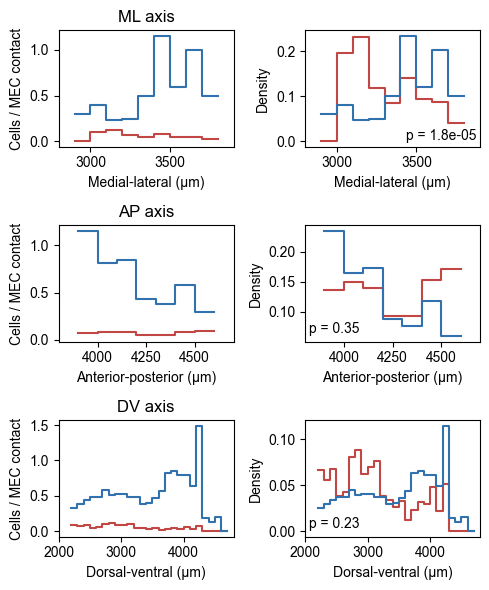

In [15]:
import numpy as np
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 2, figsize=(5, 6))  # smaller size

# Divide by 2 to correct for double counting, and rename variables
gcs_per_contact_ml_div2 = gcs_per_contact_ml / 2
ngs_per_contact_ml_div2 = ngs_per_contact_ml / 2
gcs_per_contact_ap_div2 = gcs_per_contact_ap / 2
ngs_per_contact_ap_div2 = ngs_per_contact_ap / 2
gcs_per_contact_dv_div2 = gcs_per_contact_dv / 2
ngs_per_contact_dv_div2 = ngs_per_contact_dv / 2

# ML axis
axes[0, 0].step(ml_bins[:-1], gcs_per_contact_ml_div2, where='post', color='#c04744')
axes[0, 0].step(ml_bins[:-1], ngs_per_contact_ml_div2, where='post', color='#3171ae')
axes[0, 0].set_xlabel('Medial-lateral (µm)')
axes[0, 0].set_ylabel('Cells / MEC contact')
axes[0, 0].set_title('ML axis', fontsize=12, fontweight='normal')

gcs_density_ml = gcs_per_contact_ml_div2 / np.nansum(gcs_per_contact_ml_div2)
ngs_density_ml = ngs_per_contact_ml_div2 / np.nansum(ngs_per_contact_ml_div2)
axes[0, 1].step(ml_bins[:-1], gcs_density_ml, where='post', color='#c04744')
axes[0, 1].step(ml_bins[:-1], ngs_density_ml, where='post', color='#3171ae')
axes[0, 1].set_xlabel('Medial-lateral (µm)')
axes[0, 1].set_ylabel('Density')


# Annotate with LMM p-value for ML
axes[0, 1].annotate(
    f"p = {result_ml.pvalues['group[T.NGS]:bin']:.2g}",
    xy=(0.98, 0.15), xycoords='axes fraction',
    ha='right', va='top', fontsize=10
)

# Set same x limits for ML row
ml_xlim = (2800, 3900)
axes[0, 0].set_xlim(ml_xlim)
axes[0, 1].set_xlim(ml_xlim)

# AP axis
axes[1, 0].step(ap_bins[:-1], gcs_per_contact_ap_div2, where='post', color='#c04744')
axes[1, 0].step(ap_bins[:-1], ngs_per_contact_ap_div2, where='post', color='#3171ae')
axes[1, 0].set_xlabel('Anterior-posterior (µm)')
axes[1, 0].set_ylabel('Cells / MEC contact')
axes[1, 0].set_title('AP axis', fontsize=12, fontweight='normal')

gcs_density_ap = gcs_per_contact_ap_div2 / np.nansum(gcs_per_contact_ap_div2)
ngs_density_ap = ngs_per_contact_ap_div2 / np.nansum(ngs_per_contact_ap_div2)
axes[1, 1].step(ap_bins[:-1], gcs_density_ap, where='post', color='#c04744')
axes[1, 1].step(ap_bins[:-1], ngs_density_ap, where='post', color='#3171ae')
axes[1, 1].set_xlabel('Anterior-posterior (µm)')
axes[1, 1].set_ylabel('Density')

# Annotate with LMM p-value for AP
axes[1, 1].annotate(
    f"p = {result_ap.pvalues['group[T.NGS]:bin']:.2g}",
    xy=(0.02, 0.05), xycoords='axes fraction',
    ha='left', va='bottom', fontsize=10
)

# Set same x limits for AP row
ap_xlim = (3800, 4700)
axes[1, 0].set_xlim(ap_xlim)
axes[1, 1].set_xlim(ap_xlim)

# DV axis
axes[2, 0].step(dv_bins[:-1], gcs_per_contact_dv_div2, where='post', color='#c04744')
axes[2, 0].step(dv_bins[:-1], ngs_per_contact_dv_div2, where='post', color='#3171ae')
axes[2, 0].set_xlabel('Dorsal-ventral (µm)')
axes[2, 0].set_ylabel('Cells / MEC contact')
axes[2, 0].set_title('DV axis', fontsize=12, fontweight='normal')

gcs_density_dv = gcs_per_contact_dv_div2 / np.nansum(gcs_per_contact_dv_div2)
ngs_density_dv = ngs_per_contact_dv_div2 / np.nansum(ngs_per_contact_dv_div2)
axes[2, 1].step(dv_bins[:-1], gcs_density_dv, where='post', color='#c04744')
axes[2, 1].step(dv_bins[:-1], ngs_density_dv, where='post', color='#3171ae')
axes[2, 1].set_xlabel('Dorsal-ventral (µm)')
axes[2, 1].set_ylabel('Density')

# Annotate with LMM p-value for DV
axes[2, 1].annotate(
    f"p = {result_dv.pvalues['group[T.NGS]:bin']:.2g}",
    xy=(0.02, 0.05), xycoords='axes fraction',
    ha='left', va='bottom', fontsize=10
)

# Set same x limits for DV row
dv_xlim = (2000, 4800)
axes[2, 0].set_xlim(dv_xlim)
axes[2, 1].set_xlim(dv_xlim)

plt.tight_layout()
plt.savefig('/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_2_anatomy_of_spatial_cells/cells_per_contact_per_axis_ENTonly_cumulative.pdf', bbox_inches='tight', dpi=300)
plt.show()

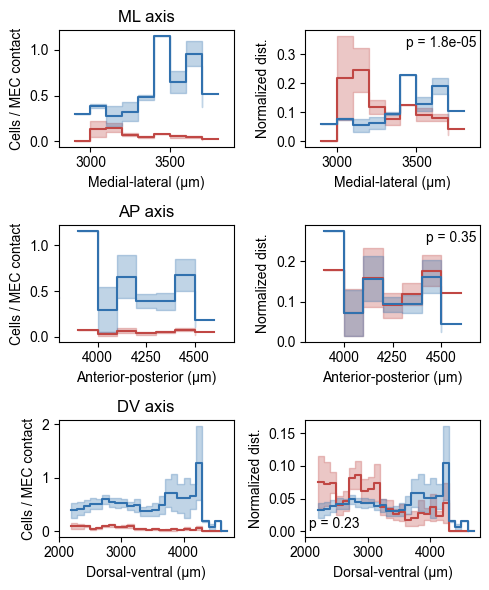

In [16]:
import numpy as np
import matplotlib.pyplot as plt

# --- Compute per-mouse histograms for each axis and cell type ---
n_mice = len(mouse_ids)
n_bins_ml = len(ml_bins) - 1
n_bins_ap = len(ap_bins) - 1
n_bins_dv = len(dv_bins) - 1

gcs_hist_ml = np.full((n_mice, n_bins_ml), np.nan)
ngs_hist_ml = np.full((n_mice, n_bins_ml), np.nan)
gcs_hist_ap = np.full((n_mice, n_bins_ap), np.nan)
ngs_hist_ap = np.full((n_mice, n_bins_ap), np.nan)
gcs_hist_dv = np.full((n_mice, n_bins_dv), np.nan)
ngs_hist_dv = np.full((n_mice, n_bins_dv), np.nan)

for i_mouse, mouse in enumerate(mouse_ids):
    gcs_mouse = gcs_ent[gcs_ent['mouse'] == mouse]
    ngs_mouse = ngs_ent[ngs_ent['mouse'] == mouse]
    contacts_mouse = ent_contacts[ent_contacts['mouse'] == mouse]

    # ML axis
    contacts_ml, _ = np.histogram(contacts_mouse['coord_SCs_x'] * -1, bins=ml_bins)
    gcs_ml, _ = np.histogram(gcs_mouse['coord_SCs_x'] * -1, bins=ml_bins)
    ngs_ml, _ = np.histogram(ngs_mouse['coord_SCs_x'] * -1, bins=ml_bins)
    gcs_hist_ml[i_mouse] = np.divide(gcs_ml, contacts_ml, out=np.full_like(gcs_ml, np.nan, dtype=float), where=contacts_ml > 0)
    ngs_hist_ml[i_mouse] = np.divide(ngs_ml, contacts_ml, out=np.full_like(ngs_ml, np.nan, dtype=float), where=contacts_ml > 0)

    # AP axis
    contacts_ap, _ = np.histogram(contacts_mouse['coord_SCs_z'], bins=ap_bins)
    gcs_ap, _ = np.histogram(gcs_mouse['coord_SCs_z'], bins=ap_bins)
    ngs_ap, _ = np.histogram(ngs_mouse['coord_SCs_z'], bins=ap_bins)
    gcs_hist_ap[i_mouse] = np.divide(gcs_ap, contacts_ap, out=np.full_like(gcs_ap, np.nan, dtype=float), where=contacts_ap > 0)
    ngs_hist_ap[i_mouse] = np.divide(ngs_ap, contacts_ap, out=np.full_like(ngs_ap, np.nan, dtype=float), where=contacts_ap > 0)

    # DV axis
    contacts_dv, _ = np.histogram(contacts_mouse['coord_SCs_y'], bins=dv_bins)
    gcs_dv, _ = np.histogram(gcs_mouse['coord_SCs_y'], bins=dv_bins)
    ngs_dv, _ = np.histogram(ngs_mouse['coord_SCs_y'], bins=dv_bins)
    gcs_hist_dv[i_mouse] = np.divide(gcs_dv, contacts_dv, out=np.full_like(gcs_dv, np.nan, dtype=float), where=contacts_dv > 0)
    ngs_hist_dv[i_mouse] = np.divide(ngs_dv, contacts_dv, out=np.full_like(ngs_dv, np.nan, dtype=float), where=contacts_dv > 0)

# --- Average and SEM across mice ---
def mean_sem(arr):
    mean = np.nanmean(arr, axis=0)
    sem = np.nanstd(arr, axis=0) / np.sqrt(np.sum(~np.isnan(arr), axis=0))
    return mean, sem

gcs_ml_mean, gcs_ml_sem = mean_sem(gcs_hist_ml)
ngs_ml_mean, ngs_ml_sem = mean_sem(ngs_hist_ml)
gcs_ap_mean, gcs_ap_sem = mean_sem(gcs_hist_ap)
ngs_ap_mean, ngs_ap_sem = mean_sem(ngs_hist_ap)
gcs_dv_mean, gcs_dv_sem = mean_sem(gcs_hist_dv)
ngs_dv_mean, ngs_dv_sem = mean_sem(ngs_hist_dv)

# --- Plot average ± SEM using step and fill_between ---
fig, axes = plt.subplots(3, 2, figsize=(5, 6))

def plot_step_with_sem(ax, bins, mean, sem, color, label=None, div2=False):
    y = mean / 2 if div2 else mean
    yerr = sem / 2 if div2 else sem
    ax.step(bins[:-1], y, where='post', color=color, label=label)
    ax.fill_between(bins[:-1], y - yerr, y + yerr, step='post', color=color, alpha=0.3)

# ML axis
plot_step_with_sem(axes[0, 0], ml_bins, gcs_ml_mean, gcs_ml_sem, '#c04744', label='GCS', div2=True)
plot_step_with_sem(axes[0, 0], ml_bins, ngs_ml_mean, ngs_ml_sem, '#3171ae', label='NGS', div2=True)
axes[0, 0].set_xlabel('Medial-lateral (µm)')
axes[0, 0].set_ylabel('Cells / MEC contact')
axes[0, 0].set_title('ML axis', fontsize=12, fontweight='normal')

gcs_density_ml = gcs_ml_mean / np.nansum(gcs_ml_mean)
ngs_density_ml = ngs_ml_mean / np.nansum(ngs_ml_mean)
gcs_density_ml_sem = gcs_ml_sem / np.nansum(gcs_ml_mean)
ngs_density_ml_sem = ngs_ml_sem / np.nansum(ngs_ml_mean)
plot_step_with_sem(axes[0, 1], ml_bins, gcs_density_ml, gcs_density_ml_sem, '#c04744')
plot_step_with_sem(axes[0, 1], ml_bins, ngs_density_ml, ngs_density_ml_sem, '#3171ae')
axes[0, 1].set_xlabel('Medial-lateral (µm)')
axes[0, 1].set_ylabel('Normalized dist.')
axes[0, 1].annotate(
    f"p = {result_ml.pvalues['group[T.NGS]:bin']:.2g}",
    xy=(0.98, 0.95), xycoords='axes fraction',
    ha='right', va='top', fontsize=10
)
ml_xlim = (2800, 3900)
axes[0, 0].set_xlim(ml_xlim)
axes[0, 1].set_xlim(ml_xlim)

# AP axis
plot_step_with_sem(axes[1, 0], ap_bins, gcs_ap_mean, gcs_ap_sem, '#c04744', div2=True)
plot_step_with_sem(axes[1, 0], ap_bins, ngs_ap_mean, ngs_ap_sem, '#3171ae', div2=True)
axes[1, 0].set_xlabel('Anterior-posterior (µm)')
axes[1, 0].set_ylabel('Cells / MEC contact')
axes[1, 0].set_title('AP axis', fontsize=12, fontweight='normal')

gcs_density_ap = gcs_ap_mean / np.nansum(gcs_ap_mean)
ngs_density_ap = ngs_ap_mean / np.nansum(ngs_ap_mean)
gcs_density_ap_sem = gcs_ap_sem / np.nansum(gcs_ap_mean)
ngs_density_ap_sem = ngs_ap_sem / np.nansum(ngs_ap_mean)
plot_step_with_sem(axes[1, 1], ap_bins, gcs_density_ap, gcs_density_ap_sem, '#c04744')
plot_step_with_sem(axes[1, 1], ap_bins, ngs_density_ap, ngs_density_ap_sem, '#3171ae')
axes[1, 1].set_xlabel('Anterior-posterior (µm)')
axes[1, 1].set_ylabel('Normalized dist.')
axes[1, 1].annotate(
    f"p = {result_ap.pvalues['group[T.NGS]:bin']:.2g}",
    xy=(0.98, 0.95), xycoords='axes fraction',
    ha='right', va='top', fontsize=10
)
ap_xlim = (3800, 4700)
axes[1, 0].set_xlim(ap_xlim)
axes[1, 1].set_xlim(ap_xlim)

# DV axis
plot_step_with_sem(axes[2, 0], dv_bins, gcs_dv_mean, gcs_dv_sem, '#c04744', div2=True)
plot_step_with_sem(axes[2, 0], dv_bins, ngs_dv_mean, ngs_dv_sem, '#3171ae', div2=True)
axes[2, 0].set_xlabel('Dorsal-ventral (µm)')
axes[2, 0].set_ylabel('Cells / MEC contact')
axes[2, 0].set_title('DV axis', fontsize=12, fontweight='normal')

gcs_density_dv = gcs_dv_mean / np.nansum(gcs_dv_mean)
ngs_density_dv = ngs_dv_mean / np.nansum(ngs_dv_mean)
gcs_density_dv_sem = gcs_dv_sem / np.nansum(gcs_dv_mean)
ngs_density_dv_sem = ngs_dv_sem / np.nansum(ngs_dv_mean)
plot_step_with_sem(axes[2, 1], dv_bins, gcs_density_dv, gcs_density_dv_sem, '#c04744')
plot_step_with_sem(axes[2, 1], dv_bins, ngs_density_dv, ngs_density_dv_sem, '#3171ae')
axes[2, 1].set_xlabel('Dorsal-ventral (µm)')
axes[2, 1].set_ylabel('Normalized dist.')
axes[2, 1].annotate(
    f"p = {result_dv.pvalues['group[T.NGS]:bin']:.2g}",
    xy=(0.02, 0.05), xycoords='axes fraction',
    ha='left', va='bottom', fontsize=10
)
dv_xlim = (2000, 4800)
axes[2, 0].set_xlim(dv_xlim)
axes[2, 1].set_xlim(dv_xlim)

plt.tight_layout()
plt.savefig('/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_2_anatomy_of_spatial_cells/cells_per_contact_per_axis_ENTonly_cumulative_meanSEM_stepfill.pdf', bbox_inches='tight', dpi=300)
plt.show()

superficial ML axis GLMM:
            Mixed Linear Model Regression Results
Model:               MixedLM  Dependent Variable:  value   
No. Observations:    52       Method:              REML    
No. Groups:          8        Scale:               0.0923  
Min. group size:     2        Log-Likelihood:      -28.9507
Max. group size:     10       Converged:           Yes     
Mean group size:     6.5                                   
-----------------------------------------------------------
                 Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-----------------------------------------------------------
Intercept         0.915    0.882  1.038 0.299 -0.813  2.644
group[T.NGS]     -3.300    1.223 -2.698 0.007 -5.698 -0.903
bin              -0.000    0.000 -0.916 0.360 -0.001  0.000
group[T.NGS]:bin  0.001    0.000  3.143 0.002  0.000  0.002
Group Var         0.003    0.038                           

superficial AP axis GLMM:
            Mixed Linear Model Regression Results
Model: 

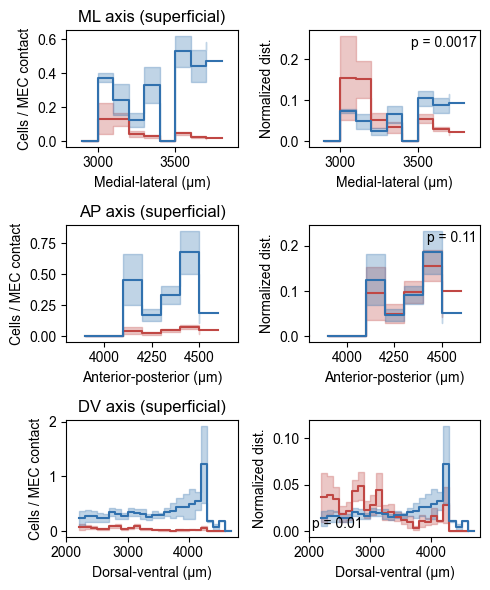

deep ML axis GLMM:
            Mixed Linear Model Regression Results
Model:               MixedLM  Dependent Variable:  value   
No. Observations:    52       Method:              REML    
No. Groups:          8        Scale:               0.1503  
Min. group size:     2        Log-Likelihood:      -42.7924
Max. group size:     10       Converged:           Yes     
Mean group size:     6.5                                   
-----------------------------------------------------------
                 Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-----------------------------------------------------------
Intercept         0.063    1.122  0.057 0.955 -2.135  2.262
group[T.NGS]     -2.655    1.561 -1.701 0.089 -5.715  0.405
bin              -0.000    0.000 -0.037 0.970 -0.001  0.001
group[T.NGS]:bin  0.001    0.000  1.934 0.053 -0.000  0.002
Group Var         0.030    0.071                           

deep AP axis GLMM:
            Mixed Linear Model Regression Results
Model:               

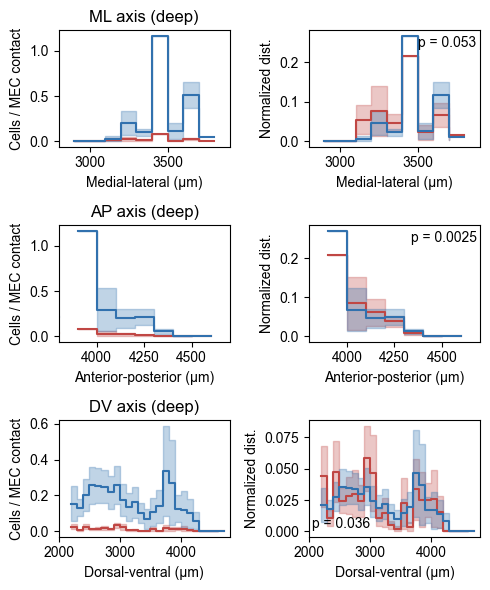

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

# Define superficial and deep regions
superficial_regions = ['ENTm1', 'ENTm2', 'ENTm3']
deep_regions = ['ENTm5', 'ENTm6', 'ENTl6a']

def subset_cells_by_region(df, regions):
    return df[df['brain_region'].isin(regions)]

# Subset grid and non-grid cells
gcs_superficial = subset_cells_by_region(gcs_, superficial_regions)
ngs_superficial = subset_cells_by_region(ngs_, superficial_regions)
gcs_deep = subset_cells_by_region(gcs_, deep_regions)
ngs_deep = subset_cells_by_region(ngs_, deep_regions)

# Subset contacts for mice (contacts are not region-specific, so use all ent_contacts)
def run_stats_and_plot(gcs_cells, ngs_cells, ent_contacts, ml_bins, ap_bins, dv_bins, mouse_ids, title_suffix):
    n_mice = len(mouse_ids)
    n_bins_ml = len(ml_bins) - 1
    n_bins_ap = len(ap_bins) - 1
    n_bins_dv = len(dv_bins) - 1

    # ML
    gcs_cells_per_entcontact_ml = np.full((n_bins_ml, n_mice), np.nan)
    ngs_cells_per_entcontact_ml = np.full((n_bins_ml, n_mice), np.nan)
    for i_mouse, mouse in enumerate(mouse_ids):
        gcs_mouse = gcs_cells[gcs_cells['mouse'] == mouse]
        ngs_mouse = ngs_cells[ngs_cells['mouse'] == mouse]
        contacts_mouse = ent_contacts[ent_contacts['mouse'] == mouse]
        gcs_counts, _ = np.histogram(gcs_mouse['coord_SCs_x'] * -1, bins=ml_bins)
        ngs_counts, _ = np.histogram(ngs_mouse['coord_SCs_x'] * -1, bins=ml_bins)
        contact_counts, _ = np.histogram(contacts_mouse['coord_SCs_x'] * -1, bins=ml_bins)
        with np.errstate(divide='ignore', invalid='ignore'):
            gcs_cells_per_entcontact_ml[:, i_mouse] = gcs_counts / contact_counts
            ngs_cells_per_entcontact_ml[:, i_mouse] = ngs_counts / contact_counts

    # AP
    gcs_cells_per_entcontact_ap = np.full((n_bins_ap, n_mice), np.nan)
    ngs_cells_per_entcontact_ap = np.full((n_bins_ap, n_mice), np.nan)
    for i_mouse, mouse in enumerate(mouse_ids):
        gcs_mouse = gcs_cells[gcs_cells['mouse'] == mouse]
        ngs_mouse = ngs_cells[ngs_cells['mouse'] == mouse]
        contacts_mouse = ent_contacts[ent_contacts['mouse'] == mouse]
        gcs_counts, _ = np.histogram(gcs_mouse['coord_SCs_z'], bins=ap_bins)
        ngs_counts, _ = np.histogram(ngs_mouse['coord_SCs_z'], bins=ap_bins)
        contact_counts, _ = np.histogram(contacts_mouse['coord_SCs_z'], bins=ap_bins)
        with np.errstate(divide='ignore', invalid='ignore'):
            gcs_cells_per_entcontact_ap[:, i_mouse] = gcs_counts / contact_counts
            ngs_cells_per_entcontact_ap[:, i_mouse] = ngs_counts / contact_counts

    # DV
    gcs_cells_per_entcontact_dv = np.full((n_bins_dv, n_mice), np.nan)
    ngs_cells_per_entcontact_dv = np.full((n_bins_dv, n_mice), np.nan)
    for i_mouse, mouse in enumerate(mouse_ids):
        gcs_mouse = gcs_cells[gcs_cells['mouse'] == mouse]
        ngs_mouse = ngs_cells[ngs_cells['mouse'] == mouse]
        contacts_mouse = ent_contacts[ent_contacts['mouse'] == mouse]
        gcs_counts, _ = np.histogram(gcs_mouse['coord_SCs_y'], bins=dv_bins)
        ngs_counts, _ = np.histogram(ngs_mouse['coord_SCs_y'], bins=dv_bins)
        contact_counts, _ = np.histogram(contacts_mouse['coord_SCs_y'], bins=dv_bins)
        with np.errstate(divide='ignore', invalid='ignore'):
            gcs_cells_per_entcontact_dv[:, i_mouse] = gcs_counts / contact_counts
            ngs_cells_per_entcontact_dv[:, i_mouse] = ngs_counts / contact_counts

    # Stats
    def make_df(arr_gcs, arr_ngs, bins, mouse_ids):
        data = []
        for i_mouse, mouse in enumerate(mouse_ids):
            for i_bin in range(len(bins)-1):
                data.append({'value': arr_gcs[i_bin, i_mouse], 'group': 'GCS', 'bin': bins[i_bin], 'mouse': mouse})
                data.append({'value': arr_ngs[i_bin, i_mouse], 'group': 'NGS', 'bin': bins[i_bin], 'mouse': mouse})
        return pd.DataFrame(data).dropna(subset=['value'])

    df_ml = make_df(gcs_cells_per_entcontact_ml, ngs_cells_per_entcontact_ml, ml_bins, mouse_ids)
    df_ap = make_df(gcs_cells_per_entcontact_ap, ngs_cells_per_entcontact_ap, ap_bins, mouse_ids)
    df_dv = make_df(gcs_cells_per_entcontact_dv, ngs_cells_per_entcontact_dv, dv_bins, mouse_ids)

    model_ml = smf.mixedlm("value ~ group * bin", df_ml, groups=df_ml["mouse"])
    result_ml = model_ml.fit(method="powell", maxiter=5000)
    model_ap = smf.mixedlm("value ~ group * bin", df_ap, groups=df_ap["mouse"])
    result_ap = model_ap.fit(method="powell", maxiter=5000)
    model_dv = smf.mixedlm("value ~ group * bin", df_dv, groups=df_dv["mouse"])
    result_dv = model_dv.fit(method="powell", maxiter=5000)

    print(f"{title_suffix} ML axis GLMM:\n", result_ml.summary())
    print(f"{title_suffix} AP axis GLMM:\n", result_ap.summary())
    print(f"{title_suffix} DV axis GLMM:\n", result_dv.summary())

    # Plot
    def mean_sem(arr):
        mean = np.nanmean(arr, axis=1)
        sem = np.nanstd(arr, axis=1) / np.sqrt(np.sum(~np.isnan(arr), axis=1))
        return mean, sem

    gcs_ml_mean, gcs_ml_sem = mean_sem(gcs_cells_per_entcontact_ml)
    ngs_ml_mean, ngs_ml_sem = mean_sem(ngs_cells_per_entcontact_ml)
    gcs_ap_mean, gcs_ap_sem = mean_sem(gcs_cells_per_entcontact_ap)
    ngs_ap_mean, ngs_ap_sem = mean_sem(ngs_cells_per_entcontact_ap)
    gcs_dv_mean, gcs_dv_sem = mean_sem(gcs_cells_per_entcontact_dv)
    ngs_dv_mean, ngs_dv_sem = mean_sem(ngs_cells_per_entcontact_dv)

    fig, axes = plt.subplots(3, 2, figsize=(5, 6))
    def plot_step_with_sem(ax, bins, mean, sem, color, label=None, div2=True):
        y = mean / 2 if div2 else mean
        yerr = sem / 2 if div2 else sem
        ax.step(bins[:-1], y, where='post', color=color, label=label)
        ax.fill_between(bins[:-1], y - yerr, y + yerr, step='post', color=color, alpha=0.3)

    # ML
    plot_step_with_sem(axes[0, 0], ml_bins, gcs_ml_mean, gcs_ml_sem, '#c04744', label='GCS')
    plot_step_with_sem(axes[0, 0], ml_bins, ngs_ml_mean, ngs_ml_sem, '#3171ae', label='NGS')
    axes[0, 0].set_xlabel('Medial-lateral (µm)')
    axes[0, 0].set_ylabel('Cells / MEC contact')
    axes[0, 0].set_title(f'ML axis ({title_suffix})')

    gcs_density_ml = gcs_ml_mean / np.nansum(gcs_ml_mean)
    ngs_density_ml = ngs_ml_mean / np.nansum(ngs_ml_mean)
    gcs_density_ml_sem = gcs_ml_sem / np.nansum(gcs_ml_mean)
    ngs_density_ml_sem = ngs_ml_sem / np.nansum(ngs_ml_mean)
    plot_step_with_sem(axes[0, 1], ml_bins, gcs_density_ml, gcs_density_ml_sem, '#c04744')
    plot_step_with_sem(axes[0, 1], ml_bins, ngs_density_ml, ngs_density_ml_sem, '#3171ae')
    axes[0, 1].set_xlabel('Medial-lateral (µm)')
    axes[0, 1].set_ylabel('Normalized dist.')
    axes[0, 1].annotate(
        f"p = {result_ml.pvalues['group[T.NGS]:bin']:.2g}",
        xy=(0.98, 0.95), xycoords='axes fraction',
        ha='right', va='top', fontsize=10
    )
    axes[0, 0].set_xlim((2800, 3900))
    axes[0, 1].set_xlim((2800, 3900))

    # AP
    plot_step_with_sem(axes[1, 0], ap_bins, gcs_ap_mean, gcs_ap_sem, '#c04744')
    plot_step_with_sem(axes[1, 0], ap_bins, ngs_ap_mean, ngs_ap_sem, '#3171ae')
    axes[1, 0].set_xlabel('Anterior-posterior (µm)')
    axes[1, 0].set_ylabel('Cells / MEC contact')
    axes[1, 0].set_title(f'AP axis ({title_suffix})')

    gcs_density_ap = gcs_ap_mean / np.nansum(gcs_ap_mean)
    ngs_density_ap = ngs_ap_mean / np.nansum(ngs_ap_mean)
    gcs_density_ap_sem = gcs_ap_sem / np.nansum(gcs_ap_mean)
    ngs_density_ap_sem = ngs_ap_sem / np.nansum(ngs_ap_mean)
    plot_step_with_sem(axes[1, 1], ap_bins, gcs_density_ap, gcs_density_ap_sem, '#c04744')
    plot_step_with_sem(axes[1, 1], ap_bins, ngs_density_ap, ngs_density_ap_sem, '#3171ae')
    axes[1, 1].set_xlabel('Anterior-posterior (µm)')
    axes[1, 1].set_ylabel('Normalized dist.')
    axes[1, 1].annotate(
        f"p = {result_ap.pvalues['group[T.NGS]:bin']:.2g}",
        xy=(0.98, 0.95), xycoords='axes fraction',
        ha='right', va='top', fontsize=10
    )
    axes[1, 0].set_xlim((3800, 4700))
    axes[1, 1].set_xlim((3800, 4700))

    # DV
    plot_step_with_sem(axes[2, 0], dv_bins, gcs_dv_mean, gcs_dv_sem, '#c04744')
    plot_step_with_sem(axes[2, 0], dv_bins, ngs_dv_mean, ngs_dv_sem, '#3171ae')
    axes[2, 0].set_xlabel('Dorsal-ventral (µm)')
    axes[2, 0].set_ylabel('Cells / MEC contact')
    axes[2, 0].set_title(f'DV axis ({title_suffix})')

    gcs_density_dv = gcs_dv_mean / np.nansum(gcs_dv_mean)
    ngs_density_dv = ngs_dv_mean / np.nansum(ngs_dv_mean)
    gcs_density_dv_sem = gcs_dv_sem / np.nansum(gcs_dv_mean)
    ngs_density_dv_sem = ngs_dv_sem / np.nansum(ngs_dv_mean)
    plot_step_with_sem(axes[2, 1], dv_bins, gcs_density_dv, gcs_density_dv_sem, '#c04744')
    plot_step_with_sem(axes[2, 1], dv_bins, ngs_density_dv, ngs_density_dv_sem, '#3171ae')
    axes[2, 1].set_xlabel('Dorsal-ventral (µm)')
    axes[2, 1].set_ylabel('Normalized dist.')
    axes[2, 1].annotate(
        f"p = {result_dv.pvalues['group[T.NGS]:bin']:.2g}",
        xy=(0.02, 0.05), xycoords='axes fraction',
        ha='left', va='bottom', fontsize=10
    )
    axes[2, 0].set_xlim((2000, 4800))
    axes[2, 1].set_xlim((2000, 4800))

    plt.tight_layout()
    plt.savefig(f'/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_2_anatomy_of_spatial_cells/cells_per_contact_per_axis_{title_suffix}_meanSEM_stepfill.pdf', bbox_inches='tight', dpi=300)
    plt.show()

# Run for superficial and deep
run_stats_and_plot(
    gcs_superficial, ngs_superficial, ent_contacts, ml_bins, ap_bins, dv_bins, mouse_ids, 'superficial'
)
run_stats_and_plot(
    gcs_deep, ngs_deep, ent_contacts, ml_bins, ap_bins, dv_bins, mouse_ids, 'deep'
)

To give us some reassurances that we're picking up on the effect of the spatial axis, we can simulate a case where the bin factor matters and one where it doesn't and use the same test to compare

In [18]:
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf

np.random.seed(42)

n_repeats = 100
pvals_case1 = []
pvals_case2 = []

for repeat in range(n_repeats):
    # Parameters
    n_bins = 10
    n_contacts_per_bin = 100
    n_cells_per_bin = 50

    # --- CASE 1: No difference between groups (GCS/NGS) or bins ---
    data_case1 = []
    for mouse in mouse_ids:
        for i_bin in range(n_bins):
            n_contacts = n_contacts_per_bin
            gcs = np.random.poisson(lam=n_cells_per_bin, size=1)[0]
            ngs = np.random.poisson(lam=n_cells_per_bin, size=1)[0]
            gcs_per_contact = gcs / n_contacts
            ngs_per_contact = ngs / n_contacts
            data_case1.append({'value': gcs_per_contact, 'group': 'GCS', 'bin': i_bin, 'mouse': mouse})
            data_case1.append({'value': ngs_per_contact, 'group': 'NGS', 'bin': i_bin, 'mouse': mouse})

    df_case1 = pd.DataFrame(data_case1)
    df_case1['group'] = df_case1['group'].astype('category')
    df_case1['mouse'] = df_case1['mouse'].astype('category')
    df_case1['bin'] = (df_case1['bin'] - df_case1['bin'].mean()) / df_case1['bin'].std()  # Standardize

    model_case1 = smf.mixedlm("value ~ group * bin", df_case1, groups=df_case1["mouse"])
    try:
        result_case1 = model_case1.fit(method="powell", maxiter=5000, disp=False)
        pval1 = result_case1.pvalues.get('group[T.NGS]:bin', np.nan)
    except Exception:
        pval1 = np.nan
    pvals_case1.append(pval1)

    # --- CASE 2: GCS has higher values in first half of bins, NGS in second half ---
    data_case2 = []
    for mouse in mouse_ids:
        for i_bin in range(n_bins):
            n_contacts = n_contacts_per_bin
            if i_bin < n_bins // 2:
                gcs = np.random.poisson(lam=n_cells_per_bin * 2, size=1)[0]
                ngs = np.random.poisson(lam=n_cells_per_bin, size=1)[0]
            else:
                gcs = np.random.poisson(lam=n_cells_per_bin, size=1)[0]
                ngs = np.random.poisson(lam=n_cells_per_bin * 2, size=1)[0]
            gcs_per_contact = gcs / n_contacts
            ngs_per_contact = ngs / n_contacts
            data_case2.append({'value': gcs_per_contact, 'group': 'GCS', 'bin': i_bin, 'mouse': mouse})
            data_case2.append({'value': ngs_per_contact, 'group': 'NGS', 'bin': i_bin, 'mouse': mouse})

    df_case2 = pd.DataFrame(data_case2)
    df_case2['group'] = df_case2['group'].astype('category')
    df_case2['mouse'] = df_case2['mouse'].astype('category')
    df_case2['bin'] = (df_case2['bin'] - df_case2['bin'].mean()) / df_case2['bin'].std()  # Standardize

    model_case2 = smf.mixedlm("value ~ group * bin", df_case2, groups=df_case2["mouse"])
    try:
        result_case2 = model_case2.fit(method="powell", maxiter=5000, disp=False)
        pval2 = result_case2.pvalues.get('group[T.NGS]:bin', np.nan)
    except Exception:
        pval2 = np.nan
    pvals_case2.append(pval2)

# Count significant results (p < 0.05)
sig_case1 = np.sum(np.array(pvals_case1) < 0.05)
sig_case2 = np.sum(np.array(pvals_case2) < 0.05)

print(f"CASE 1 (designed as NULL): group[T.NGS]:bin p < 0.05 in {sig_case1} out of {n_repeats} runs")
print(f"CASE 2 (designed as ALT): group[T.NGS]:bin p < 0.05 in {sig_case2} out of {n_repeats} runs")

CASE 1 (designed as NULL): group[T.NGS]:bin p < 0.05 in 5 out of 100 runs
CASE 2 (designed as ALT): group[T.NGS]:bin p < 0.05 in 100 out of 100 runs


from this we can see that the between cases our test can detect the differences on cell location allocated to different bins

In [19]:
device_contacts

,Unnamed: 0,device_contact_id,unit_location_x,unit_location_y,mouse,shank_id,Mouse,coord_SCs_z,coord_SCs_y,coord_SCs_x,coord_CCFs_z,coord_CCFs_y,coord_CCFs_x,brain_region
0,0,s0e0,0.0,0.0,20,0,M20,4089.885390,4351.785030,-3150.0,9876.502731,4678.713177,2550.0,ENTm1
1,1,s0e1,32.0,0.0,20,0,M20,4089.885390,4351.785030,-3150.0,9876.502731,4678.713177,2550.0,ENTm1
2,2,s0e2,0.0,15.0,20,0,M20,4091.433523,4336.865135,-3150.0,9876.666070,4662.823397,2550.0,ENTm1
3,3,s0e3,32.0,15.0,20,0,M20,4091.433523,4336.865135,-3150.0,9876.666070,4662.823397,2550.0,ENTm1
4,4,s0e4,0.0,30.0,20,0,M20,4092.981656,4321.945239,-3150.0,9876.829409,4646.933618,2550.0,ENTm1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12283,12283,s3e91,782.0,675.0,29,3,M29,4300.534479,3313.612171,-3510.0,9990.401548,3564.078828,2190.0,ENTm3
12284,12284,s3e92,750.0,690.0,29,3,M29,4299.600839,3298.641255,-3510.0,9988.087850,3548.351557,2190.0,ENTm3
12285,12285,s3e93,782.0,690.0,29,3,M29,4299.600839,3298.641255,-3510.0,9988.087850,3548.351557,2190.0,ENTm3
12286,12286,s3e94,750.0,705.0,29,3,M29,4298.667200,3283.670340,-3510.0,9985.774152,3532.624286,2190.0,ENTm3


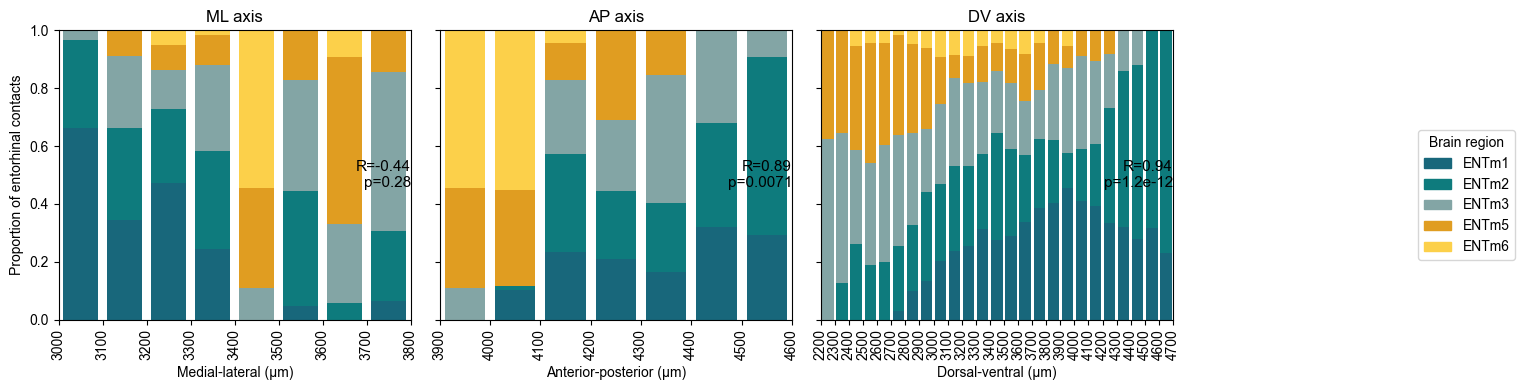

In [20]:

import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import linregress

device_contacts['coord_SCs_x'] = np.abs(device_contacts['coord_SCs_x'])  # Invert ML axis
#only keep ENT contacts
device_contacts = device_contacts[device_contacts['brain_region'].str.startswith('ENTm')]

# Define bins and labels for each axis
ml_bins = np.arange(3000, 3900, 100)
ap_bins = np.arange(3900, 4700, 100)
dv_bins = np.arange(2200, 4800, 100)
ml_bin_labels = [str(x) for x in ml_bins[:-1]]
ap_bin_labels = [str(x) for x in ap_bins[:-1]]
dv_bin_labels = [str(x) for x in dv_bins[:-1]]

# Get all unique regions (sublayers) present in device_contacts
all_sublayers = list(device_contacts['brain_region'].dropna().unique())
superficial = ['ENTm1', 'ENTm2', 'ENTm3']
deep = ['ENTl6a', 'ENTm5', 'ENTm6']

# Color map (customize as needed)
sublayer_colors = {}
for sub in all_sublayers:
    if sub == 'ENTm1':
        sublayer_colors[sub] = "#18677b"
    elif sub == 'ENTm2':
        sublayer_colors[sub] = "#0e7b7d"
    elif sub == 'ENTm3':
        sublayer_colors[sub] = "#83a5a5"
    elif sub == 'ENTm5':
        sublayer_colors[sub] = "#E09D21"
    elif sub == 'ENTm6':
        sublayer_colors[sub] = "#FCD04A"
    else:
        sublayer_colors[sub] = "#B0BEC5"

def compute_region_props(df, axis_col, bin_edges, sublayers):
    bin_idx = np.digitize(df[axis_col], bin_edges) - 1
    props = np.zeros((len(bin_edges)-1, len(sublayers)))
    for i in range(len(bin_edges)-1):
        bin_contacts = df[bin_idx == i]
        total = len(bin_contacts)
        if total > 0:
            for j, sub in enumerate(sublayers):
                props[i, j] = np.sum(bin_contacts['brain_region'] == sub) / total
        else:
            props[i, :] = np.nan
    return props

# Compute proportions for each axis
ml_props = compute_region_props(device_contacts, 'coord_SCs_x', ml_bins, all_sublayers)
ap_props = compute_region_props(device_contacts, 'coord_SCs_z', ap_bins, all_sublayers)
dv_props = compute_region_props(device_contacts, 'coord_SCs_y', dv_bins, all_sublayers)

fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharey=True)

# Helper to get indices for the desired order in the current axis
def get_ordered_indices(axis_sublayers):
    return [i for sub in all_sublayers if sub in axis_sublayers for i, s in enumerate(axis_sublayers) if s == sub]

# ML axis
ml_indices = get_ordered_indices(all_sublayers)
bottom = np.zeros(len(ml_bin_labels))
for i in ml_indices:
    sub = all_sublayers[i]
    axes[0].bar(ml_bin_labels, ml_props[:, i], bottom=bottom, color=sublayer_colors[sub], label=sub)
    bottom += ml_props[:, i]
axes[0].set_title('ML axis')
axes[0].set_xlabel('Medial-lateral (µm)')
axes[0].set_ylabel('Proportion of entorhinal contacts')
axes[0].set_xlim(-0.5, len(ml_bin_labels) - 0.5)
axes[0].set_xticks(np.arange(len(ml_bin_labels)+1)-0.5)
axes[0].set_xticklabels([str(x) for x in ml_bins], rotation=90, ha='center')

# AP axis
ap_indices = get_ordered_indices(all_sublayers)
bottom = np.zeros(len(ap_bin_labels))
for i in ap_indices:
    sub = all_sublayers[i]
    axes[1].bar(ap_bin_labels, ap_props[:, i], bottom=bottom, color=sublayer_colors[sub], label=sub)
    bottom += ap_props[:, i]
axes[1].set_title('AP axis')
axes[1].set_xlabel('Anterior-posterior (µm)')
axes[1].set_xlim(-0.5, len(ap_bin_labels) - 0.5)
axes[1].set_xticks(np.arange(len(ap_bin_labels)+1)-0.5)
axes[1].set_xticklabels([str(x) for x in ap_bins], rotation=90, ha='center')

# DV axis
dv_indices = get_ordered_indices(all_sublayers)
bottom = np.zeros(len(dv_bin_labels))
for i in dv_indices:
    sub = all_sublayers[i]
    axes[2].bar(dv_bin_labels, dv_props[:, i], bottom=bottom, color=sublayer_colors[sub], label=sub)
    bottom += dv_props[:, i]
axes[2].set_title('DV axis')
axes[2].set_xlabel('Dorsal-ventral (µm)')
axes[2].set_xlim(-0.5, len(dv_bin_labels) - 0.5)
axes[2].set_xticks(np.arange(len(dv_bin_labels)+1)-0.5)
axes[2].set_xticklabels([str(x) for x in dv_bins], rotation=90, ha='center')

# Move legend to far right
fig.legend(
    handles=[plt.Rectangle((0,0),1,1, color=sublayer_colors[sub]) for sub in all_sublayers],
    labels=[sub for sub in all_sublayers],
    title='Brain region',
    bbox_to_anchor=(1.18, 0.5),
    loc='center left'
)

# --- Add average superficial lines and regression ---
for ax, props, lims, bin_labels in zip(
    axes,
    [ml_props, ap_props, dv_props],
    [(0, len(ml_bin_labels)), (0, len(ap_bin_labels)), (0, len(dv_bin_labels))],
    [ml_bin_labels, ap_bin_labels, dv_bin_labels]
):
    superficial_idx = [i for i, s in enumerate(all_sublayers) if s in superficial]
    avg_superficial = np.nansum(props[:, superficial_idx], axis=1)
    x_vals = np.arange(lims[0], lims[1])
    slope, intercept, r_value, p_value_sup, std_err = linregress(x_vals, avg_superficial[lims[0]:lims[1]])
    #ax.plot(x_vals, avg_superficial[lims[0]:lims[1]], color='blue', lw=2, label='Superficial (1-3)')
    ax.annotate(f"R={r_value:.2g}\np={p_value_sup:.2g}", xy=(1, 0.5), xycoords='axes fraction',
                ha='right', va='center', fontsize=11, color='black',
                bbox=dict(facecolor='white', edgecolor='none', alpha=0.0))

plt.tight_layout()
plt.savefig('/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_2_anatomy_of_spatial_cells/device_contacts_brainregion_stackedbar_per_axis_proportion.pdf', bbox_inches='tight', dpi=300)
plt.show()


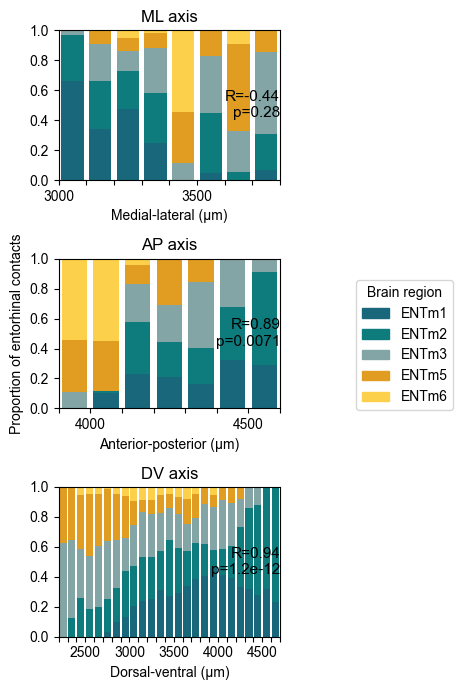

In [21]:

import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import linregress

device_contacts['coord_SCs_x'] = np.abs(device_contacts['coord_SCs_x'])  # Invert ML axis
#only keep ENT contacts
device_contacts = device_contacts[device_contacts['brain_region'].str.startswith('ENTm')]

# Define bins and labels for each axis
ml_bins = np.arange(3000, 3900, 100)
ap_bins = np.arange(3900, 4700, 100)
dv_bins = np.arange(2200, 4800, 100)
ml_bin_labels = [str(x) for x in ml_bins[:-1]]
ap_bin_labels = [str(x) for x in ap_bins[:-1]]
dv_bin_labels = [str(x) for x in dv_bins[:-1]]

# Get all unique regions (sublayers) present in device_contacts
all_sublayers = list(device_contacts['brain_region'].dropna().unique())
superficial = ['ENTm1', 'ENTm2', 'ENTm3']
deep = ['ENTl6a', 'ENTm5', 'ENTm6']

# Color map (customize as needed)
sublayer_colors = {}
for sub in all_sublayers:
    if sub == 'ENTm1':
        sublayer_colors[sub] = "#18677b"
    elif sub == 'ENTm2':
        sublayer_colors[sub] = "#0e7b7d"
    elif sub == 'ENTm3':
        sublayer_colors[sub] = "#83a5a5"
    elif sub == 'ENTm5':
        sublayer_colors[sub] = "#E09D21"
    elif sub == 'ENTm6':
        sublayer_colors[sub] = "#FCD04A"
    else:
        sublayer_colors[sub] = "#B0BEC5"

def compute_region_props(df, axis_col, bin_edges, sublayers):
    bin_idx = np.digitize(df[axis_col], bin_edges) - 1
    props = np.zeros((len(bin_edges)-1, len(sublayers)))
    for i in range(len(bin_edges)-1):
        bin_contacts = df[bin_idx == i]
        total = len(bin_contacts)
        if total > 0:
            for j, sub in enumerate(sublayers):
                props[i, j] = np.sum(bin_contacts['brain_region'] == sub) / total
        else:
            props[i, :] = np.nan
    return props

# Compute proportions for each axis
ml_props = compute_region_props(device_contacts, 'coord_SCs_x', ml_bins, all_sublayers)
ap_props = compute_region_props(device_contacts, 'coord_SCs_z', ap_bins, all_sublayers)
dv_props = compute_region_props(device_contacts, 'coord_SCs_y', dv_bins, all_sublayers)

fig, axes = plt.subplots(3, 1, figsize=(3, 7), sharey=True)

# Helper to get indices for the desired order in the current axis
def get_ordered_indices(axis_sublayers):
    return [i for sub in all_sublayers if sub in axis_sublayers for i, s in enumerate(axis_sublayers) if s == sub]

# ML axis
ml_indices = get_ordered_indices(all_sublayers)
bottom = np.zeros(len(ml_bin_labels))
for i in ml_indices:
    sub = all_sublayers[i]
    axes[0].bar(ml_bin_labels, ml_props[:, i], bottom=bottom, color=sublayer_colors[sub], label=sub)
    bottom += ml_props[:, i]
axes[0].set_title('ML axis')
axes[0].set_xlabel('Medial-lateral (µm)')
axes[1].set_ylabel('Proportion of entorhinal contacts')
axes[0].set_xlim(-0.5, len(ml_bin_labels) - 0.5)
axes[0].set_xticks(np.arange(len(ml_bin_labels)+1)-0.5)
axes[0].set_xticklabels([str(x) for x in ml_bins], rotation=0, ha='center')
# set xtick_labels to invisible if it isn't a multi of 500
for i, label in enumerate(axes[0].get_xticklabels()):
    if int(label.get_text()) % 500 != 0:
        label.set_visible(False)

# AP axis
ap_indices = get_ordered_indices(all_sublayers)
bottom = np.zeros(len(ap_bin_labels))
for i in ap_indices:
    sub = all_sublayers[i]
    axes[1].bar(ap_bin_labels, ap_props[:, i], bottom=bottom, color=sublayer_colors[sub], label=sub)
    bottom += ap_props[:, i]
axes[1].set_title('AP axis')
axes[1].set_xlabel('Anterior-posterior (µm)')
axes[1].set_xlim(-0.5, len(ap_bin_labels) - 0.5)
axes[1].set_xticks(np.arange(len(ap_bin_labels)+1)-0.5)
axes[1].set_xticklabels([str(x) for x in ap_bins], rotation=0, ha='center')
for i, label in enumerate(axes[1].get_xticklabels()):
    if int(label.get_text()) % 500 != 0:
        label.set_visible(False)

# DV axis
dv_indices = get_ordered_indices(all_sublayers)
bottom = np.zeros(len(dv_bin_labels))
for i in dv_indices:
    sub = all_sublayers[i]
    axes[2].bar(dv_bin_labels, dv_props[:, i], bottom=bottom, color=sublayer_colors[sub], label=sub)
    bottom += dv_props[:, i]
axes[2].set_title('DV axis')
axes[2].set_xlabel('Dorsal-ventral (µm)')
axes[2].set_xlim(-0.5, len(dv_bin_labels) - 0.5)
axes[2].set_xticks(np.arange(len(dv_bin_labels)+1)-0.5)
axes[2].set_xticklabels([str(x) for x in dv_bins], rotation=0, ha='center')
# set xtick_labels to invisible if it isn't a multi of 500
for i, label in enumerate(axes[2].get_xticklabels()):
    if int(label.get_text()) % 500 != 0:
        label.set_visible(False)

# Move legend to far right
fig.legend(
    handles=[plt.Rectangle((0,0),1,1, color=sublayer_colors[sub]) for sub in all_sublayers],
    labels=[sub for sub in all_sublayers],
    title='Brain region',
    bbox_to_anchor=(1.18, 0.5),
    loc='center left'
)

# --- Add average superficial lines and regression ---
for ax, props, lims, bin_labels in zip(
    axes,
    [ml_props, ap_props, dv_props],
    [(0, len(ml_bin_labels)), (0, len(ap_bin_labels)), (0, len(dv_bin_labels))],
    [ml_bin_labels, ap_bin_labels, dv_bin_labels]
):
    superficial_idx = [i for i, s in enumerate(all_sublayers) if s in superficial]
    avg_superficial = np.nansum(props[:, superficial_idx], axis=1)
    x_vals = np.arange(lims[0], lims[1])
    slope, intercept, r_value, p_value_sup, std_err = linregress(x_vals, avg_superficial[lims[0]:lims[1]])
    #ax.plot(x_vals, avg_superficial[lims[0]:lims[1]], color='blue', lw=2, label='Superficial (1-3)')
    ax.annotate(f"R={r_value:.2g}\np={p_value_sup:.2g}", xy=(1, 0.5), xycoords='axes fraction',
                ha='right', va='center', fontsize=11, color='black',
                bbox=dict(facecolor='white', edgecolor='none', alpha=0.0))

plt.tight_layout()
plt.savefig('/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_2_anatomy_of_spatial_cells/device_contacts_brainregion_stackedbar_per_axis_proportion.pdf', bbox_inches='tight', dpi=300)
plt.show()
